In [1]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.spatial.distance import pdist, squareform
from pathlib import Path
import prince
import dash
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince
from sklearn.model_selection import LeaveOneOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.linear_model import ElasticNet
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.patches import Ellipse
from difflib import get_close_matches
from sklearn.impute import KNNImputer
import plotly.graph_objects as go
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from scipy.cluster.hierarchy import linkage, dendrogram
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
import plotly.express as px
from sklearn.neighbors import NearestNeighbors



# Data Aggregation: Combining Sample and Control Compound Files

In [13]:
import os
import glob
import yaml
import importlib
import compound_analysis_module2 as cam
import importlib
importlib.reload(cam)
# -----------------------------
# Load config
# -----------------------------
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\config.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths = config.get("data_paths", config.get("paths", {}))

# -----------------------------
# Read paths from config
# -----------------------------
sample_files = paths.get("sample_files", [])
base_compound_dir = paths.get("base_compound_dir", "")
output_path = paths.get("output_path", "")

blank_files = paths.get("blank_files", [])
env_files = paths.get("env_files", [])


# fallback: auto-detect blanks (procedural + env)
if not blank_files:
    blank_files = glob.glob(
        os.path.join(base_compound_dir, "day_*", "*blank*.csv")
    ) + glob.glob(
        os.path.join(base_compound_dir, "day_*", "*env*.csv")
    )

# -----------------------------
# Sanity checks
# -----------------------------
print(f"Samples listed manually: {len(sample_files)}")
print(f"Blank files found: {len(blank_files)}")

print("\nBlank files used:")
for bf in blank_files:
    print("  -", bf)

# -----------------------------
# Run compound combination + blank filtering
# -----------------------------
combined_df = cam.combine_compound_data(
    sample_files=sample_files,
    env_files=env_files,
    blank_files=blank_files,
    output_path=output_path
)



Samples listed manually: 94
Blank files found: 1

Blank files used:
  - C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/analysis with mz/monfared_compound_2024/blank.csv

Combined file saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/combined.csv

FileType counts (raw, before filtering):
FileType
sample    18334
env          22
blank        12
Name: count, dtype: int64

Preview of combined data:
   Component RT                  Compound Name  Match Factor  Best Hit  \
0      1.999217                        Propene     65.242228      True   
1      2.177691        2-Propanone, 1-methoxy-     87.899550      True   
2      2.359333            Propanal, 2-methyl-     78.339167      True   
3      2.465450  l-2-Amino-4-methyl-1-pentanol     68.259874      True   
4      2.504033        Undecane, 2,2-dimethyl-     68.175810      True   

   Formula  Base Peak MZ FileType   FileName  RI  
0     C3H6     40.959613   sample  ADORA.csv NaN  


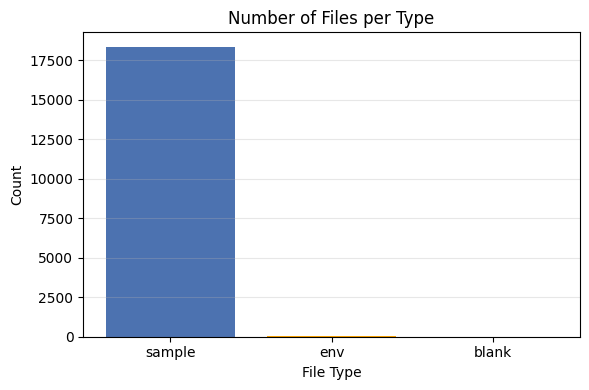

 File type count plot generated successfully.
FileType
sample    18334
env          22
blank        12
Name: count, dtype: int64


In [15]:


from compound_analysis_module2 import plot_filetype_counts

plot_filetype_counts(combined_df)


In [ ]:
pip install fuzzywuzzy[speedup]


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Contamination filtering

Sample compounds before filtering: 18334
Sample compounds after filtering: 16602
Removed 1732 sample peaks (ΔRT ≤ 0.4)


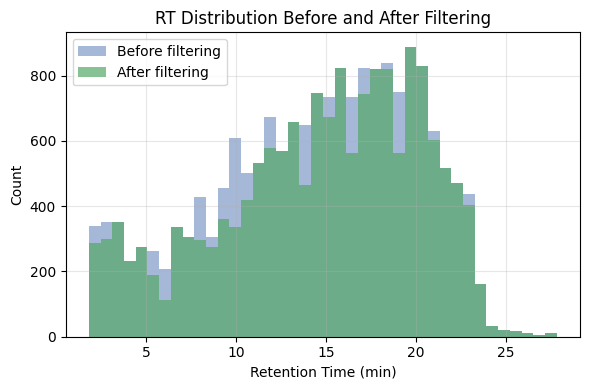

✅ RT distribution plot generated successfully.


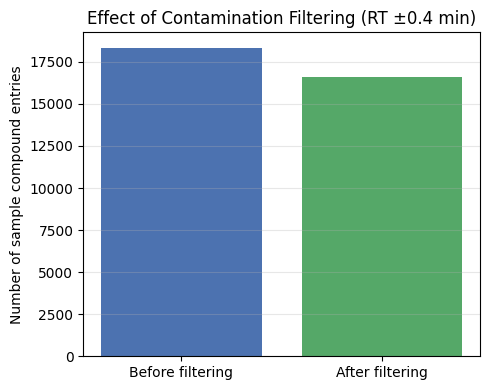

 Filtering effect plot generated successfully. (Before: 18334, After: 16602)


In [22]:
import importlib
import compound_analysis_module2 as cam
importlib.reload(cam)

real_compounds = cam.filter_real_compounds(combined_df, rt_tolerance=0.4)

cam.plot_rt_distribution(combined_df, real_compounds)
cam.plot_filtering_effect(combined_df, real_compounds, rt_tolerance=0.4)


# Matching NIST-Identified Compounds with GC–MS Peak Intensities

In [23]:
import importlib
import compound_analysis_module2 as cam
importlib.reload(cam)

from compound_analysis_module2 import match_compounds_to_peaks

# Read the config file for gc mass data
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Access the path from config
csv_path = config["paths"]["samples_filtered"]

# Load the data
matched_df, unmatched_df = match_compounds_to_peaks(
    compound_df=real_compounds,   # ⬅️ فقط compoundهای واقعی
    samples_filtered_path=csv_path,
    output_path="compound_intensity_matched.csv",
    rt_tolerance=0.4,
    mz_tolerance=1
)


Loaded 58844 GC–MS peaks


c:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\compound_analysis_module2.py:352: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mz_candidates["rt_diff"] = np.abs(mz_candidates["tR_best"] - rt)
c:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\compound_analysis_module2.py:352: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mz_candidates["rt_diff"] = np.abs(mz_candidates["tR_best"] - rt)
c:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\compound_


Matched compounds: 12865
Unmatched compounds: 3737
Saved matched table to: compound_intensity_matched.csv


In [24]:
matched_df.isnull().sum()

Variety                0
Compound Name          0
Component RT           0
Base Peak MZ           0
Matched Peak           0
tR_best                0
m/z                    0
Intensity_corrected    0
RT_diff                0
dtype: int64

# Checking the presence of known potato aroma compounds

In [ ]:
# import os, re, glob, yaml, importlib
# import numpy as np
# import pandas as pd
# from difflib import get_close_matches
# from collections import OrderedDict, defaultdict

# import compound_analysis_module as cam
# importlib.reload(cam)

# # =========================================================
# # 0) Load config
# # =========================================================
# config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\config.yaml"
# with open(config_path, "r", encoding="utf-8") as f:
#     config = yaml.safe_load(f)

# paths = config.get("data_paths", config.get("paths", {}))

# sample_files = paths.get("sample_files", [])
# base_compound_dir = paths.get("base_compound_dir", "")
# output_path = paths.get("output_path", "")

# blank_files = paths.get("blank_files", [])
# if not blank_files and base_compound_dir:
#     blank_files = glob.glob(os.path.join(base_compound_dir, "day_*", "*blank*.csv"))

# print(f"Samples listed manually: {len(sample_files)}")
# print(f"Blank files found: {len(blank_files)}")

# # =========================================================
# # 1) Build compound_df
# # =========================================================
# compound_df = cam.combine_compound_data(
#     sample_files=sample_files,
#     base_dir=base_compound_dir,
#     output_path=output_path,
#     blank_files=blank_files
# )

# # =========================================================
# # 2) Output directory
# # =========================================================
# aroma_output_path = paths.get("aroma_output", paths.get("aroma_output_path", "aroma_output.csv"))
# out_dir = os.path.dirname(aroma_output_path) if os.path.dirname(aroma_output_path) else "."
# os.makedirs(out_dir, exist_ok=True)

# # =========================================================
# # 3) Potato aroma list (core + optional)
# # =========================================================
# POTATO_AROMAS_CORE = [
#     "Hexanal","Heptanal","Octanal","Nonanal","Decanal",
#     "Pentanal","Propanal",
#     "2-Methylbutanal","3-Methylbutanal","Butanal, 3-methyl-",
#     "4-Heptenal","2-Pentenal","2-Hexenal","2-Octenal","2-Nonenal","2-Heptenal",
#     "2-Trans-nonenal","2-Trans-octenal",
#     "2,4-Heptadienal","2,4-Octadienal",
#     "(E, E)-2,4-Nonadienal","(E, Z)-2,4-Decadienal","(E, E)-2,4-Decadienal","2,4-Nonadienal",
#     "Benzaldehyde","2-methyl-Benzaldehyde","4-methyl-Benzaldehyde",
#     "Benzeneacetaldehyde","Phenylacetaldehyde",

#     "1-Heptanol","1-Nonanol","1-Octen-3-ol","1-Pentanol","3-Nonen-1-ol",
#     "Hexanol","Phenylethyl alcohol","1-Phenylethanol",
#     "2-Methyl-1-propanol","3-Methyl-1-butanol","Ethanol","Benzyl alcohol",

#     "2-Heptanone","2-Nonanone","3-Heptanone","3-Octanone","3-Octen-2-one","1-Penten-3-one",
#     "2,3-Butanedione","2,3-Pentanedione","Acetophenone","4-Methyl-2-pentanone",
#     "(E, E)-3,5-Octadien-2-one","3,5-Octadien-2-one",

#     "Acetic acid","Butanoic acid","Hexanoic acid","Isobutyric acid","Isovaleric acid",
#     "Propanoic acid","Octanoic acid","2-Octenoic acid","Decanoic acid","nonanoic acid",

#     "Methanethiol","Methional",
#     "Dimethyl sulfide","Dimethyl disulfide","Dimethyl trisulfide","Dimethyl tetrasulfide",
#     "Carbon disulfide","Hydrogen sulfide",
#     "2-Methyl-3-furanthiol","3-Methylthiopropanal","3-(Methylthio)propanal",
#     "2-Acetylthiazole","2-Methyl-3-thiazoline","2-Methylthiazole","Allyl methyl sulfide",

#     "Ethyl acetate","Isoamyl acetate","Ethyl butanoate","Ethyl hexanoate","Methyl butanoate",
#     "Ethyl 2-methylbutanoate","Ethyl propanoate","Methyl propanoate","Ethyl pentanoate",

#     "2-Acetylpyrazine","2-Ethyl-3,5-dimethylpyrazine",
#     "2-Isobutyl-3-methoxypyrazine","2-Isopropyl-3-methoxypyrazine",
#     "2-Ethyl-3-methylpyrazine","Trimethylpyrazine","Tetramethylpyrazine",
#     "2,5-Dimethylpyrazine","2,6-Dimethylpyrazine","2-Methylpyrazine",

#     "Furfural","5-Methylfurfural","3-Furaldehyde",
#     "methyl-Cyclopentane","n-Hexane",
#     "2-n-Butyl furan","cis-2-(2-Pentenyl) furan",
#     "2-pentyl-Furan","Furan, 2-pentyl-","2-Pentylfuran","2-(2-propenyl)-Furan",
#     "1,2-dimethoxy-Benzene","2-methoxy-Phenol","Methyl salicylate","Mequinol",

#     "Copaene","trans-beta-Ionone","Linalool","alpha-Terpineol",".alpha.-Terpineol",
#     "Dimethyl phthalate",
#     "Undecanal","Dodecanal",
#     "(E)-2-Hexenal","(E)-2-Heptenal","(E)-2-Decenal",
#     "2-Octenal, (E)-","2-Nonenal, (E)-",
#     "2(3H)-Furanone, dihydro-5-pentyl-",
# ]

# POTATO_AROMAS_OPTIONAL = [
#     "Phenol",
#     "Benzoic acid",
#     "Benzoic acid, methyl ester",

#     "Eucalyptol",
#     "Limonene",
#     "3-Carene",

#     "Tridecanal",
#     "Tetradecanal",
#     "2-Undecenal",
#     "2-Tridecenal",

#     "6-Methyl-5-hepten-2-one",
#     "2-Methylpropanal",
#     "1-Octyn-3-ol",
#     "3-Methylfuran",
#     "2-Ethylfuran",
#     "2-Acetyl-5-methylfuran",

#     "Acetic acid, ethenyl ester",
#     "Acetic acid, methyl ester",
#     "Butanoic acid, butyl ester",
#     "Hexanoic acid, methyl ester",
#     "Octanoic acid, methyl ester",
#     "Dodecanoic acid",
#     "Dodecanoic acid, 1-methylethyl ester",

#     "1-Hexanol, 2-ethyl-",
#     "Styrene",
#     "n-Hexadecanoic acid",
#     "Ethanol, 2-phenoxy-",
#     "Tridecane",
#     "Tetradecane",
#     "Hexadecane",
#     "2-Propanone, 1-methoxy-",
#     "2-Decanone",
#     "3-Heptanone, 4-methyl-",
#     "Methyl 8-oxooctanoate",
#     "Nonanoic acid, 9-oxo-, methyl ester",
# ]

# potato_aromas = list(OrderedDict.fromkeys(POTATO_AROMAS_CORE + POTATO_AROMAS_OPTIONAL))

# # =========================================================
# # 4) Helpers: normalize + alias + collision-safe canonical mapping
# # =========================================================
# def strip_stereo(s: str) -> str:
#     s = "" if pd.isna(s) else str(s)
#     s = re.sub(r"\(\s*[EeZz]\s*,\s*[EeZz]\s*\)", "", s)
#     s = re.sub(r"\(\s*[EeZz]\s*\)", "", s)
#     s = re.sub(r"\b(cis|trans)\b\s*-?", "", s, flags=re.IGNORECASE)
#     return s

# def normalize(s: str) -> str:
#     s = strip_stereo(s).lower().strip()
#     return re.sub(r"[^a-z0-9]+", "", s)

# ALIASES = {
#     "Phenylacetaldehyde": ["benzeneacetaldehyde"],
#     "Phenylethyl alcohol": ["2phenylethanol", "phenethyl alcohol", "phenylethanol", "2-phenylethanol"],
#     "alpha-Terpineol": [".alpha.-terpineol", "alphaterpineol", "alpha terpineol"],
#     "Furan, 2-pentyl-": ["2pentylfuran", "2-pentylfuran", "2-pentyl furan", "furan, 2-pentyl"],

#     "Dimethyl disulfide": ["disulfide, dimethyl"],
#     "Dimethyl sulfide": ["sulfide, dimethyl"],
#     "Dimethyl trisulfide": ["trisulfide, dimethyl"],

#     "Butanal, 3-methyl-": ["3-methylbutanal", "butanal,3-methyl-", "3-methyl butanal"],
#     "2-Octenal, (E)-": ["(e)-2-octenal", "2-octenal (e)", "2-octenal, (e)-"],
#     "2-Nonenal, (E)-": ["(e)-2-nonenal", "2-nonenal (e)", "2-nonenal, (e)-"],

#     # useful extra
#     "2-Methylbutanal": ["butanal, 2-methyl-", "2-methyl butanal", "2-methylbutyraldehyde"],
#     "3-Methylbutanal": ["butanal, 3-methyl-", "isovaleraldehyde", "3-methyl butanal"],

#     "6-Methyl-5-hepten-2-one": ["5-hepten-2-one, 6-methyl-", "sulcatone"],
#     "2-Methylpropanal": ["propanal, 2-methyl-", "isobutyraldehyde"],

#     "2-Undecenal": ["(e)-2-undecenal", "2-undecenal (e)", "2-undecenal, (e)-"],
#     "2-Tridecenal": ["(e)-2-tridecenal", "2-tridecenal (e)", "2-tridecenal, (e)-"],

#     "3-Methylfuran": ["furan, 3-methyl-"],
#     "2-Ethylfuran": ["furan, 2-ethyl-"],

#     "Acetic acid, ethenyl ester": ["vinyl acetate"],
#     "Acetic acid, methyl ester": ["methyl acetate"],
#     "Butanoic acid, butyl ester": ["butyl butanoate"],
#     "Hexanoic acid, methyl ester": ["methyl hexanoate"],
#     "Octanoic acid, methyl ester": ["methyl octanoate"],
#     "Dodecanoic acid, 1-methylethyl ester": ["isopropyl dodecanoate"],

#     "1-Hexanol, 2-ethyl-": ["2-ethyl-1-hexanol", "2-ethylhexanol"],
#     "n-Hexadecanoic acid": ["palmitic acid", "hexadecanoic acid"],
#     "Ethanol, 2-phenoxy-": ["phenoxyethanol", "2-phenoxyethanol"],

#     "Benzoic acid, methyl ester": ["methyl benzoate"],
#     "Eucalyptol": ["1,8-cineole", "cineole"],
#     "Limonene": ["d-limonene", "dl-limonene"],
#     "3-Carene": ["delta-3-carene", "δ-3-carene"],

#     "2-Propanone, 1-methoxy-": ["1-methoxy-2-propanone", "propylene glycol monomethyl ether"],
# }

# # collision-safe: norm -> list of original names
# by_norm = defaultdict(list)
# for x in potato_aromas:
#     by_norm[normalize(x)].append(x)

# def pick_canonical(names):
#     prefs = ["(E, E)", "(E, Z)", "(E)-", "alpha-", ".alpha.-", ", (E)-"]
#     for p in prefs:
#         for n in names:
#             if p in n:
#                 return n
#     return sorted(names, key=lambda s: (len(s), s))[0]

# canon_norm = {k: pick_canonical(v) for k, v in by_norm.items()}

# # map all variants -> chosen canonical
# syn_to_canon = {}
# for norm_key, names in by_norm.items():
#     canon = canon_norm[norm_key]
#     for n in names:
#         syn_to_canon[normalize(n)] = canon

# # add aliases -> canonical
# for canon, alts in ALIASES.items():
#     for a in alts:
#         syn_to_canon[normalize(a)] = canon

# canon_keys = list(canon_norm.keys())

# def map_to_canonical(name: str, cutoff: float = 0.86):
#     n = normalize(name)
#     if n in syn_to_canon:
#         return syn_to_canon[n], "exact/alias"

#     for ck in canon_keys:
#         if len(ck) >= 6 and ck in n:
#             return canon_norm[ck], "substring"

#     hit = get_close_matches(n, canon_keys, n=1, cutoff=cutoff)
#     if hit:
#         return canon_norm[hit[0]], "fuzzy"
#     return None, "no"

# # =========================================================
# # 5) Load peaks (samples_filtered.csv)
# # =========================================================
# samples_filtered_path = paths.get(
#     "samples_filtered",
#     r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/samples_filtered.csv"
# )

# peaks = pd.read_csv(samples_filtered_path, sep=None, engine="python").copy()

# if "Variety" not in peaks.columns:
#     raise KeyError("samples_filtered.csv must contain a 'Variety' column.")

# int_candidates = ["Intensity_corrected", "Intensity", "Area", "height", "PeakHeight", "Height"]
# INT_COL = next((c for c in int_candidates if c in peaks.columns), None)
# if INT_COL is None:
#     raise KeyError(f"No intensity column found. Tried: {int_candidates}")

# rt_col = "tR_best" if "tR_best" in peaks.columns else None
# if rt_col is None:
#     raise KeyError("samples_filtered.csv must contain 'tR_best'")

# mz_col = "m/z" if "m/z" in peaks.columns else ("mz" if "mz" in peaks.columns else None)
# if mz_col is None:
#     raise KeyError("samples_filtered.csv must contain 'm/z' or 'mz'")

# peaks[rt_col] = pd.to_numeric(peaks[rt_col], errors="coerce")
# peaks[mz_col] = pd.to_numeric(peaks[mz_col], errors="coerce")
# peaks[INT_COL] = pd.to_numeric(peaks[INT_COL], errors="coerce")
# peaks = peaks.dropna(subset=["Variety", rt_col, mz_col, INT_COL]).copy()
# peaks["_mz_round"] = peaks[mz_col].round(0)

# print("Peaks loaded:", peaks.shape, "| unique varieties:", peaks["Variety"].nunique())

# # =========================================================
# # 6) Prepare compound reference (RT/MZ) from compound_df
# # =========================================================
# compound_rt_col = next((c for c in ["tR_best","Component RT","tR","rt","RT","retention_time","RetentionTime"]
#                         if c in compound_df.columns), None)
# compound_mz_col = next((c for c in ["Base Peak MZ","Base Peak m/z","Base Peak m/z ","mz","m/z","MZ","mass","Mass"]
#                         if c in compound_df.columns), None)
# name_col = next((c for c in ["Compound Name","Name","Best Hit","Library Name","Hit Name","Compound"]
#                  if c in compound_df.columns), None)

# if compound_rt_col is None or compound_mz_col is None or name_col is None:
#     raise KeyError(
#         f"compound_df must contain Name + RT + MZ columns.\n"
#         f"Detected name={name_col}, rt={compound_rt_col}, mz={compound_mz_col}\n"
#         f"Available columns: {compound_df.columns.tolist()}"
#     )

# cdf = compound_df.copy()
# cdf[name_col] = cdf[name_col].astype(str)
# cdf[compound_rt_col] = pd.to_numeric(cdf[compound_rt_col], errors="coerce")
# cdf[compound_mz_col] = pd.to_numeric(cdf[compound_mz_col], errors="coerce")
# cdf = cdf.dropna(subset=[name_col, compound_rt_col, compound_mz_col]).copy()

# # map names to canonical aroma
# cdf["Compound Name"], cdf["_match_type"] = zip(*cdf[name_col].map(map_to_canonical))
# cdf = cdf[cdf["Compound Name"].notna()].copy()

# ref = (cdf.groupby("Compound Name", as_index=False)
#          .agg(rt_ref=(compound_rt_col, "median"),
#               mz_ref=(compound_mz_col, "median"),
#               n_hits=("Compound Name", "size")))

# ref_path = os.path.join(out_dir, "aroma_reference_rt_mz.csv")
# ref.to_csv(ref_path, index=False)

# print("Reference aromas found:", ref["Compound Name"].nunique(), "/", len(potato_aromas))
# print("Saved reference:", ref_path)

# # Debug: what is missing from reference
# missing_list = [x for x in potato_aromas if normalize(x) not in set(ref["Compound Name"].map(normalize))]
# missing_df = pd.DataFrame({"Compound Name": missing_list})
# missing_ref_path = os.path.join(out_dir, "missing_aromas_from_reference.csv")
# missing_df.to_csv(missing_ref_path, index=False)
# print("Missing from reference:", len(missing_list), "->", missing_ref_path)

# # (Optional) dump unmapped names for alias debugging
# unmapped = cdf[cdf["_match_type"].eq("no")] if "_match_type" in cdf.columns else pd.DataFrame()
# unmapped_path = os.path.join(out_dir, "compound_df_unmapped_names.csv")
# if not unmapped.empty:
#     unmapped[[name_col]].drop_duplicates().to_csv(unmapped_path, index=False)
#     print("Saved unmapped compound_df names:", unmapped_path)

# # =========================================================
# # 7) Match per variety (RT+MZ strict) + fallback nearest (stored separately)
# # =========================================================
# rt_tol = float(paths.get("rt_tol", 0.4))
# mz_tol = float(paths.get("mz_tol", 0.5))

# rows = []
# for variety, pv in peaks.groupby("Variety", sort=False):
#     pv = pv.copy()

#     for _, r in ref.iterrows():
#         cname = r["Compound Name"]
#         rt_ref = float(r["rt_ref"])
#         mz_ref = float(r["mz_ref"])
#         mz_round_ref = round(mz_ref)

#         # first filter by rounded mz neighborhood
#         cand = pv[np.abs(pv["_mz_round"] - mz_round_ref) <= 1].copy()
#         if cand.empty:
#             cand = pv.copy()

#         cand["_rt_diff"] = (cand[rt_col] - rt_ref).abs()
#         cand["_mz_diff"] = (cand[mz_col] - mz_ref).abs()

#         strict = cand[(cand["_rt_diff"] <= rt_tol) & (cand["_mz_diff"] <= mz_tol)].copy()

#         if strict.empty:
#             used = cand
#             match_method = "nearest_fallback"
#         else:
#             used = strict
#             match_method = "RT+MZ"

#         used["_score"] = (used["_rt_diff"] / max(rt_tol, 1e-9)) + (used["_mz_diff"] / max(mz_tol, 1e-9))
#         best = used.sort_values("_score").iloc[0]

#         ok = (float(best["_rt_diff"]) <= rt_tol) and (float(best["_mz_diff"]) <= mz_tol)

#         rows.append({
#             "Variety": variety,
#             "Compound Name": cname,
#             "tR_best": float(best[rt_col]),
#             "m/z": float(best[mz_col]),
#             "peak_Intensity": float(best[INT_COL]),
#             "peak_Intensity_strict": float(best[INT_COL]) if ok else np.nan,
#             "match_method": match_method,
#             "is_fallback": (not ok),
#             "_rt_diff": float(best["_rt_diff"]),
#             "_mz_diff": float(best["_mz_diff"]),
#         })

# matched_per_variety = pd.DataFrame(rows)

# matched_out = os.path.join(out_dir, "matched_per_variety_WITH_MZ_RT.csv")
# matched_per_variety.to_csv(matched_out, index=False)

# print("matched_per_variety shape:", matched_per_variety.shape)
# print("unique varieties:", matched_per_variety["Variety"].nunique())
# print("unique aromas:", matched_per_variety["Compound Name"].nunique())
# print("Saved:", matched_out)

# # =========================================================
# # 8) QC outputs (VERY IMPORTANT)
# # =========================================================
# qc = (matched_per_variety
#       .groupby("Compound Name", as_index=False)
#       .agg(
#           n=("Variety", "size"),
#           strict_rate=("is_fallback", lambda s: 1 - float(np.mean(s))),
#           fallback_rate=("is_fallback", "mean"),
#           rt_p95=("_rt_diff", lambda x: float(np.nanpercentile(x, 95))),
#           mz_p95=("_mz_diff", lambda x: float(np.nanpercentile(x, 95))),
#       )
#       .sort_values("fallback_rate", ascending=False)
# )

# qc_path = os.path.join(out_dir, "match_qc_summary.csv")
# qc.to_csv(qc_path, index=False)

# fallback_long = matched_per_variety.loc[matched_per_variety["is_fallback"],
#                                        ["Variety","Compound Name","tR_best","m/z","_rt_diff","_mz_diff","peak_Intensity","match_method"]]
# fallback_long_path = os.path.join(out_dir, "filled_by_fallback_long.csv")
# fallback_long.to_csv(fallback_long_path, index=False)

# print("Saved QC summary:", qc_path)
# print("Saved fallback long:", fallback_long_path)

# print("Overall fallback rate:", float(matched_per_variety["is_fallback"].mean()))
# print(matched_per_variety["match_method"].value_counts())

# # =========================================================
# # 9) Build matrices
# # =========================================================
# mat_all = (matched_per_variety
#            .pivot_table(index="Variety", columns="Compound Name", values="peak_Intensity", aggfunc="median"))

# mat_strict = (matched_per_variety
#               .pivot_table(index="Variety", columns="Compound Name", values="peak_Intensity_strict", aggfunc="median"))

# # save
# mat_all_0 = mat_all.fillna(0).reset_index()
# mat_strict_NA = mat_strict.reset_index()  # keep NaN (recommended for GWAS QC)

# out_all = os.path.join(out_dir, "aroma_matrix_ALL_fill0.csv")
# out_strict = os.path.join(out_dir, "aroma_matrix_STRICT_NA.csv")

# mat_all_0.to_csv(out_all, index=False)
# mat_strict_NA.to_csv(out_strict, index=False)

# print("Saved:", out_all)
# print("Saved:", out_strict)

# # =========================================================
# # 10) Simple sanity prints
# # =========================================================
# print("\nTop fallback compounds:")
# print(qc.head(15)[["Compound Name","fallback_rate","rt_p95","mz_p95","n"]])

# print("\nIf you want GWAS/effect size: use aroma_matrix_STRICT_NA.csv + filter compounds with strict_rate high (e.g. >0.8).")


Detected potato aromas: 48 / 58
Missing aromas: 10


In [37]:
# =========================================================
# Imports
# =========================================================
import os, re, glob, yaml
import numpy as np
import pandas as pd
from difflib import get_close_matches
from collections import OrderedDict, defaultdict

# =========================================================
# 0) Load config
# =========================================================
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\config.yaml"
with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths = config.get("data_paths", config.get("paths", {}))


# =========================================================
# Imports
# =========================================================
import re
import pandas as pd
from difflib import get_close_matches
from collections import OrderedDict, defaultdict



print("matched_df shape:", matched_df.shape)
print("Columns:", matched_df.columns.tolist())

# =========================================================
# 2) Potato aroma lists (EXACTLY AS YOU PROVIDED)
# =========================================================
POTATO_AROMAS_CORE = [
    "Hexanal","Heptanal","Octanal","Nonanal","Decanal",
    "Pentanal","Propanal",
    "2-Methylbutanal","3-Methylbutanal","Butanal, 3-methyl-",
    "4-Heptenal","2-Pentenal","2-Hexenal","2-Octenal","2-Nonenal","2-Heptenal",
    "2-Trans-nonenal","2-Trans-octenal",
    "2,4-Heptadienal","2,4-Octadienal",
    "(E, E)-2,4-Nonadienal","(E, Z)-2,4-Decadienal","(E, E)-2,4-Decadienal","2,4-Nonadienal",
    "Benzaldehyde","2-methyl-Benzaldehyde","4-methyl-Benzaldehyde",
    "Benzeneacetaldehyde","Phenylacetaldehyde",

    "1-Heptanol","1-Nonanol","1-Octen-3-ol","1-Pentanol","3-Nonen-1-ol",
    "Hexanol","Phenylethyl alcohol","1-Phenylethanol",
    "2-Methyl-1-propanol","3-Methyl-1-butanol","Ethanol","Benzyl alcohol",

    "2-Heptanone","2-Nonanone","3-Heptanone","3-Octanone","3-Octen-2-one","1-Penten-3-one",
    "2,3-Butanedione","2,3-Pentanedione","Acetophenone","4-Methyl-2-pentanone",
    "(E, E)-3,5-Octadien-2-one","3,5-Octadien-2-one",

    "Acetic acid","Butanoic acid","Hexanoic acid","Isobutyric acid","Isovaleric acid",
    "Propanoic acid","Octanoic acid","2-Octenoic acid","Decanoic acid","nonanoic acid",

    "Methanethiol","Methional",
    "Dimethyl sulfide","Dimethyl disulfide","Dimethyl trisulfide","Dimethyl tetrasulfide",
    "Carbon disulfide","Hydrogen sulfide",
    "2-Methyl-3-furanthiol","3-Methylthiopropanal","3-(Methylthio)propanal",
    "2-Acetylthiazole","2-Methyl-3-thiazoline","2-Methylthiazole","Allyl methyl sulfide",

    "Ethyl acetate","Isoamyl acetate","Ethyl butanoate","Ethyl hexanoate","Methyl butanoate",
    "Ethyl 2-methylbutanoate","Ethyl propanoate","Methyl propanoate","Ethyl pentanoate",

    "2-Acetylpyrazine","2-Ethyl-3,5-dimethylpyrazine",
    "2-Isobutyl-3-methoxypyrazine","2-Isopropyl-3-methoxypyrazine",
    "2-Ethyl-3-methylpyrazine","Trimethylpyrazine","Tetramethylpyrazine",
    "2,5-Dimethylpyrazine","2,6-Dimethylpyrazine","2-Methylpyrazine",

    "Furfural","5-Methylfurfural","3-Furaldehyde",
    "methyl-Cyclopentane","n-Hexane",
    "2-n-Butyl furan","cis-2-(2-Pentenyl) furan",
    "2-pentyl-Furan","Furan, 2-pentyl-","2-Pentylfuran","2-(2-propenyl)-Furan",
    "1,2-dimethoxy-Benzene","2-methoxy-Phenol","Methyl salicylate","Mequinol",

    "Copaene","trans-beta-Ionone","Linalool","alpha-Terpineol",".alpha.-Terpineol",
    "Dimethyl phthalate",
    "Undecanal","Dodecanal",
    "(E)-2-Hexenal","(E)-2-Heptenal","(E)-2-Decenal",
    "2-Octenal, (E)-","2-Nonenal, (E)-",
    "2(3H)-Furanone, dihydro-5-pentyl-",
]

POTATO_AROMAS_OPTIONAL = [
    "Phenol","Benzoic acid","Benzoic acid, methyl ester",
    "Eucalyptol","Limonene","3-Carene",
    "Tridecanal","Tetradecanal","2-Undecenal","2-Tridecenal",
    "6-Methyl-5-hepten-2-one","2-Methylpropanal","1-Octyn-3-ol",
    "3-Methylfuran","2-Ethylfuran","2-Acetyl-5-methylfuran",
    "Acetic acid, ethenyl ester","Acetic acid, methyl ester",
    "Butanoic acid, butyl ester","Hexanoic acid, methyl ester",
    "Octanoic acid, methyl ester","Dodecanoic acid",
    "Dodecanoic acid, 1-methylethyl ester",
    "1-Hexanol, 2-ethyl-","Styrene","n-Hexadecanoic acid",
    "Ethanol, 2-phenoxy-","Tridecane","Tetradecane","Hexadecane",
    "2-Propanone, 1-methoxy-","2-Decanone","3-Heptanone, 4-methyl-",
    "Methyl 8-oxooctanoate","Nonanoic acid, 9-oxo-, methyl ester",
]

potato_aromas = list(OrderedDict.fromkeys(
    POTATO_AROMAS_CORE + POTATO_AROMAS_OPTIONAL
))

print("Total reference potato aromas:", len(potato_aromas))

# =========================================================
# 3) Normalization
# =========================================================
def strip_stereo(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\(\s*[EeZz][^)]*\)", "", s)
    s = re.sub(r"\b(cis|trans)\b", "", s, flags=re.I)
    return s

def normalize(s):
    return re.sub(r"[^a-z0-9]+", "", strip_stereo(s).lower())

# =========================================================
# 4) ALIASES (EXACTLY AS YOU PROVIDED)
# =========================================================
ALIASES = {
    "Phenylacetaldehyde": ["benzeneacetaldehyde"],
    "Phenylethyl alcohol": ["2phenylethanol","phenethyl alcohol","phenylethanol","2-phenylethanol"],
    "alpha-Terpineol": [".alpha.-terpineol","alphaterpineol","alpha terpineol"],
    "Furan, 2-pentyl-": ["2pentylfuran","2-pentylfuran","2-pentyl furan","furan, 2-pentyl"],
    "Dimethyl disulfide": ["disulfide, dimethyl"],
    "Dimethyl sulfide": ["sulfide, dimethyl"],
    "Dimethyl trisulfide": ["trisulfide, dimethyl"],
    "Butanal, 3-methyl-": ["3-methylbutanal","butanal,3-methyl-","3-methyl butanal"],
    "2-Octenal, (E)-": ["(e)-2-octenal","2-octenal (e)"],
    "2-Nonenal, (E)-": ["(e)-2-nonenal","2-nonenal (e)"],
    "2-Methylbutanal": ["butanal, 2-methyl-","2-methylbutyraldehyde"],
    "3-Methylbutanal": ["isovaleraldehyde"],
    "6-Methyl-5-hepten-2-one": ["5-hepten-2-one, 6-methyl-","sulcatone"],
    "2-Methylpropanal": ["propanal, 2-methyl-","isobutyraldehyde"],
    "3-Methylfuran": ["furan, 3-methyl-"],
    "2-Ethylfuran": ["furan, 2-ethyl-"],
    "Acetic acid, ethenyl ester": ["vinyl acetate"],
    "Acetic acid, methyl ester": ["methyl acetate"],
    "Benzoic acid, methyl ester": ["methyl benzoate"],
    "Eucalyptol": ["1,8-cineole","cineole"],
    "Limonene": ["d-limonene","dl-limonene"],
    "3-Carene": ["delta-3-carene","δ-3-carene"],
    "2-Propanone, 1-methoxy-": ["1-methoxy-2-propanone","propylene glycol monomethyl ether"],
}

# =========================================================
# 5) Canonical mapping
# =========================================================
by_norm = defaultdict(list)
for a in potato_aromas:
    by_norm[normalize(a)].append(a)

canon_norm = {k: sorted(v, key=len)[0] for k,v in by_norm.items()}

syn_to_canon = {}
for k,v in by_norm.items():
    for n in v:
        syn_to_canon[normalize(n)] = canon_norm[k]

for canon, alts in ALIASES.items():
    for a in alts:
        syn_to_canon[normalize(a)] = canon

def map_to_canonical(name, cutoff=0.85):
    n = normalize(name)
    if n in syn_to_canon:
        return syn_to_canon[n], "exact/alias"
    hit = get_close_matches(n, canon_norm.keys(), n=1, cutoff=cutoff)
    if hit:
        return canon_norm[hit[0]], "fuzzy"
    return None, "no_match"

# =========================================================
# 6) Detect compound column
# =========================================================
NAME_COL = next(
    (c for c in ["Compound Name","compound","Aroma","Name"] if c in matched_df.columns),
    None
)

if NAME_COL is None:
    raise KeyError("No compound-name column found in matched_df")

# =========================================================
# 7) Apply detection
# =========================================================
mapped = matched_df[NAME_COL].astype(str).apply(map_to_canonical)

matched_df["Canonical_Aroma"] = mapped.map(lambda x: x[0])
matched_df["Match_Type"] = mapped.map(lambda x: x[1])

# =========================================================
# 8) Results
# =========================================================
detected = sorted(matched_df["Canonical_Aroma"].dropna().unique())
missing = sorted(
    a for a in potato_aromas
    if normalize(a) not in set(map(normalize, detected))
)

matched_df.to_csv("matched_df_with_aromas.csv", index=False)
pd.DataFrame({"Detected_Aroma": detected}).to_csv("detected_potato_aromas.csv", index=False)
pd.DataFrame({"Missing_Aroma": missing}).to_csv("missing_potato_aromas.csv", index=False)

print("DONE")
print(f"Detected aromas: {len(detected)} / {len(potato_aromas)}")
print(f"Missing aromas: {len(missing)}")
matched_df


matched_df shape: (12865, 11)
Columns: ['Variety', 'Compound Name', 'Component RT', 'Base Peak MZ', 'Matched Peak', 'tR_best', 'm/z', 'Intensity_corrected', 'RT_diff', 'Canonical_Aroma', 'Match_Type']
Total reference potato aromas: 161
DONE
Detected aromas: 74 / 161
Missing aromas: 78


,Variety,Compound Name,Component RT,Base Peak MZ,Matched Peak,tR_best,m/z,Intensity_corrected,RT_diff,Canonical_Aroma,Match_Type
0,CECILE,"Octanoic acid, 1a,2,5,5a,6,9,10,10a-octahydro-...",1.803000,39.960000,1,1.906,40,16937.355249,0.103000,None,no_match
1,VIOLET QUEEN,"Curan-17-oic acid, 2,16-didehydro-19-hydroxy-,...",1.809533,53.950000,11,2.208,53,103377.432150,0.398467,None,no_match
2,MEMPHIS,"9,10-Anthracenedione, 1,2,3,4-tetrahydro-1,2,3...",1.812517,43.914148,2,1.955,44,253446.926516,0.142483,None,no_match
3,CARRERA,"Perhydroindene-4-carboxylic acid, 6-acetoxy-2,...",1.816033,44.943685,2,1.955,44,429923.484223,0.138967,None,no_match
4,TETON RUSSET,"2,4a,7-Trihydroxy-1-methyl-8-methylenegibb-3-e...",1.819217,39.960727,1,1.906,40,26018.889472,0.086783,None,no_match
...,...,...,...,...,...,...,...,...,...,...,...
12860,DONALD,"4H-1-Benzopyran-4-one, 5,7-dihydroxy-2-methyl-...",23.492349,205.000000,623,23.331,205,30548.121610,0.161349,None,no_match
12861,FORTUS,"Methanone, 2-benzofuranylphenyl-",23.494050,221.968931,618,23.159,221,100553.369900,0.335050,None,no_match
12862,AVENGER,"Methanone, 2-benzofuranylphenyl-",23.494067,221.980000,618,23.159,221,49345.613559,0.335067,None,no_match
12863,CLEARWATER R,"Methanone, 2-benzofuranylphenyl-",23.494067,221.993162,618,23.159,221,642555.661832,0.335067,None,no_match


In [ ]:
import pandas as pd



print("Original rows:", matched_df.shape)

# keep only real potato aromas
matched_df_aroma = matched_df[
    matched_df["Canonical_Aroma"].notna()
].copy()

print("Rows with potato aromas:", matched_df_aroma.shape)
print("Unique aromas:", matched_df_aroma["Canonical_Aroma"].nunique())
print("Unique varieties:", matched_df_aroma["Variety"].nunique())
matched_df_aroma.isnull().sum()

Original rows: (12865, 11)
Rows with potato aromas: (2653, 11)
Unique aromas: 74
Unique varieties: 93


Variety                0
Compound Name          0
Component RT           0
Base Peak MZ           0
Matched Peak           0
tR_best                0
m/z                    0
Intensity_corrected    0
RT_diff                0
Canonical_Aroma        0
Match_Type             0
dtype: int64

In [76]:
# =========================================================
# Build aroma matrix WITHOUT technical zeros
# (nearest RT peak per Variety × Aroma)
# =========================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Assumptions:
# matched_df already exists and contains at least:
# Variety
# Canonical_Aroma
# Intensity_corrected
# RT_diff
# ---------------------------------------------------------

# 1) Keep only rows with valid potato aromas
df = matched_df.copy()
df = df[df["Canonical_Aroma"].notna()].copy()

print("Rows after aroma filtering:", df.shape)

# ---------------------------------------------------------
# 2) For each (Variety × Aroma), select the best peak
# Priority:
#   1) smallest RT_diff
#   2) highest intensity
# ---------------------------------------------------------
df_best = (
    df
    .sort_values(
        by=["Variety", "Canonical_Aroma", "RT_diff", "Intensity_corrected"],
        ascending=[True, True, True, False]
    )
    .groupby(["Variety", "Canonical_Aroma"], as_index=False)
    .first()
)

print("Best peak table shape:", df_best.shape)
print("Unique varieties:", df_best["Variety"].nunique())
print("Unique aromas:", df_best["Canonical_Aroma"].nunique())

# ---------------------------------------------------------
# 3) Build aroma intensity matrix (NO fillna yet)
# ---------------------------------------------------------
aroma_matrix = (
    df_best
    .pivot(
        index="Variety",
        columns="Canonical_Aroma",
        values="Intensity_corrected"
    )
)

print("Raw aroma matrix shape:", aroma_matrix.shape)

# ---------------------------------------------------------
# 4) Replace missing values with small epsilon
# (below detection limit, NOT zero)
# ---------------------------------------------------------
min_nonzero = aroma_matrix[aroma_matrix > 0].min().min()
epsilon = min_nonzero * 0.01   # 1% of smallest detected signal

aroma_matrix_filled = aroma_matrix.fillna(epsilon)

# ---------------------------------------------------------
# 5) Final sanity checks
# ---------------------------------------------------------
print("Any zeros left?:", (aroma_matrix_filled == 0).any().any())
print("Any NaNs left?:", aroma_matrix_filled.isna().any().any())

# ---------------------------------------------------------
# 6) Save GWAS-ready matrix
# ---------------------------------------------------------
out_path = "aroma_matrix_NO_TECHNICAL_ZERO.csv"
aroma_matrix_filled.reset_index().to_csv(out_path, index=False)

print("✅ DONE")
print("Saved:", out_path)
print("Matrix shape:", aroma_matrix_filled.shape)


Rows after aroma filtering: (2653, 11)
Best peak table shape: (2246, 11)
Unique varieties: 93
Unique aromas: 74
Raw aroma matrix shape: (93, 74)
Any zeros left?: False
Any NaNs left?: False
✅ DONE
Saved: aroma_matrix_NO_TECHNICAL_ZERO.csv
Matrix shape: (93, 74)


In [98]:
present_aromas = set(
    c for c in aroma_matrix.columns
    if c != "Variety"
)

missing_aromas = sorted(
    a for a in potato_aromas
    if a not in present_aromas
)

missing_aromas[50:]


['5-Methylfurfural',
 'Allyl methyl sulfide',
 'Benzaldehyde',
 'Benzeneacetaldehyde',
 'Carbon disulfide',
 'Copaene',
 'Dimethyl tetrasulfide',
 'Ethanol',
 'Ethyl 2-methylbutanoate',
 'Ethyl acetate',
 'Ethyl butanoate',
 'Ethyl hexanoate',
 'Ethyl pentanoate',
 'Ethyl propanoate',
 'Heptanal',
 'Hexanal',
 'Hydrogen sulfide',
 'Isoamyl acetate',
 'Isobutyric acid',
 'Isovaleric acid',
 'Mequinol',
 'Methanethiol',
 'Methyl butanoate',
 'Methyl propanoate',
 'Methyl salicylate',
 'Nonanal',
 'Octanal',
 'Phenol',
 'Phenylethyl alcohol',
 'Propanal',
 'Propanoic acid',
 'Styrene',
 'Tetramethylpyrazine',
 'Trimethylpyrazine',
 'cis-2-(2-Pentenyl) furan',
 'methyl-Cyclopentane',
 'trans-beta-Ionone']

# Adding Sensory Descriptions to Identified Aroma Compounds

In [49]:
import importlib
import yaml
# import compound_analysis_module as cam

# aroma_sample_df= pd.read_csv("matched_per_variety_WITH_MZ_RT.csv")

# # importlib.reload(cam)

# # --- Load config ---
# def load_config(path="config.yaml"):
#     with open(path, "r", encoding="utf-8") as f:
#         return yaml.safe_load(f)

# config = load_config()

# # --- Output path ---
# aroma_with_descriptions_output = config["paths"]["aroma_with_descriptions_output"]

# # --- Add descriptions ---
# aroma_sample_df = cam.add_aroma_descriptions(aroma_sample_df)

# --- Save ---
# aroma_sample_df.to_csv(aroma_with_descriptions_output, index=False)
# print(f"Aroma compounds with descriptions saved to:\n{aroma_with_descriptions_output}")
# aroma_sample_df=pd.read_csv('aroma_matrix_NO_NAN.csv').set_index('Variety')
# aroma_sample_df

# Classification of Aroma Compounds by Chemical Family

In [ ]:
# import importlib
# import compound_analysis_module
# importlib.reload(compound_analysis_module)

# from compound_analysis_module import assign_aroma_descriptions_and_families

# print(assign_aroma_descriptions_and_families)

# aroma_sample_df, AROMA_DESCRIPTIONS, CHEMICAL_FAMILY_MAP = assign_aroma_descriptions_and_families(aroma_sample_df)
# import json


# with open("aroma_descriptions.json", "w", encoding="utf-8") as f:
#     json.dump(AROMA_DESCRIPTIONS, f, ensure_ascii=False, indent=2)

# with open("chemical_family_map.json", "w", encoding="utf-8") as f:
#     json.dump(CHEMICAL_FAMILY_MAP, f, ensure_ascii=False, indent=2)

# # use the function directly from the module
# aroma_sample_df, AROMA_DESCRIPTIONS, CHEMICAL_FAMILY_MAP = assign_aroma_descriptions_and_families(aroma_sample_df)
# aroma_sample_df

In [ ]:
# import importlib
# import compound_analysis_module
# importlib.reload(compound_analysis_module)

# from compound_analysis_module import plot_aroma_family_distribution
# importlib.reload(compound_analysis_module)
# plot_aroma_family_distribution(aroma_sample_df)


Using columns for dedupe: ['Compound Name', 'Component RT', 'm/z']
Total aroma peaks before removing duplicates: 12865
Unique aroma peaks after filtering: 12202
Unique compound names: 2231


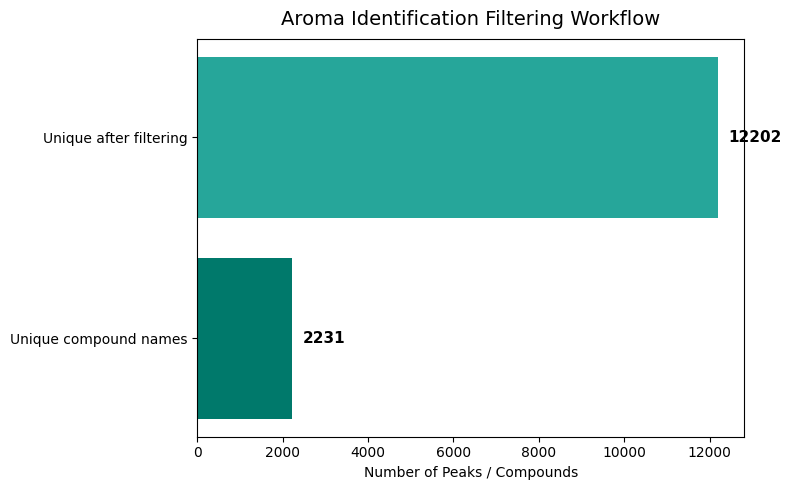

In [81]:

import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)

from compound_analysis_module import plot_aroma_filtering_funnel

# Run the function
unique_aroma_df = plot_aroma_filtering_funnel(matched_df)


In [79]:

# import importlib
# import compound_analysis_module
# importlib.reload(compound_analysis_module)
# from compound_analysis_module import summarize_and_visualize_aroma_compounds

# summary_df = summarize_and_visualize_aroma_compounds(
#     aroma_sample_df=aroma_matrix,
#     aroma_json_path="aroma_descriptions.json",
#     family_json_path="chemical_family_map.json",
#     output_path=r"C:\Users\fatemehm\Documents\aroma_summary_all_47.xlsx"
# )

# Creating the Aroma Compound Intensity Matrix

In [78]:
# import importlib
# import yaml
# import compound_analysis_module
# from compound_analysis_module import create_aroma_intensity_matrix

# # --- Reload your module (useful inside notebooks) ---
# importlib.reload(compound_analysis_module)

# # --- Load paths from config.yaml ---
# def load_config(path="config.yaml"):
#     with open(path, "r") as f:
#         return yaml.safe_load(f)

# config = load_config()

# # --- Get aroma matrix output path from config ---
# aroma_matrix_output_path = config["paths"]["aroma_matrix_output"]

# # --- Create intensity matrix ---
# aroma_matrix = create_aroma_intensity_matrix(aroma_sample_df)

# # --- Save using path from config ---
# aroma_matrix.to_csv(aroma_matrix_output_path, index=False)
# print(f" Aroma intensity matrix saved to:\n{aroma_matrix_output_path}")
#aroma_sample_df


# Run PCA and clustering 

Explained variance (2 PCs): 20.77%
Optimal number of clusters (based on silhouette): 2


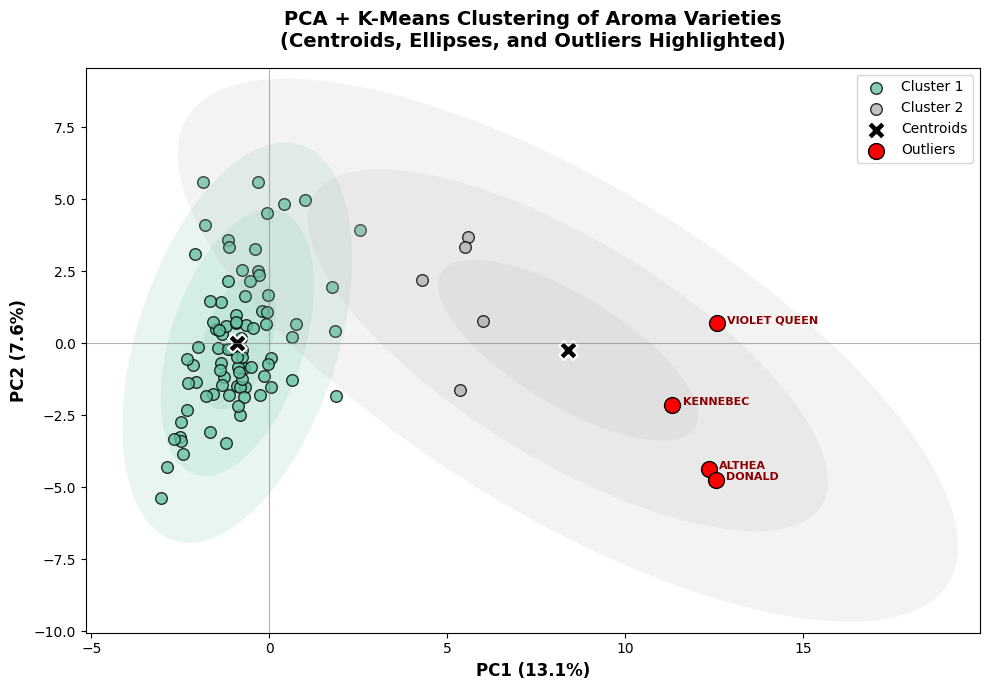


Results saved in: aroma_pca_kmeans


In [77]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import pca_kmeans_aroma


results, X_pca, clusters = pca_kmeans_aroma(aroma_matrix_filled)


Optimal PCA components: 34 (explains 90.1% variance)


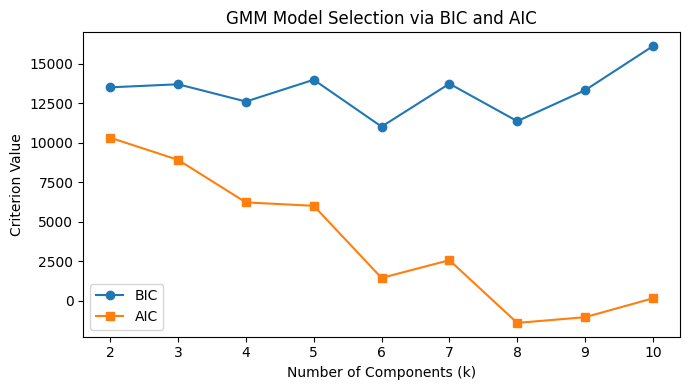

Best number of clusters (based on BIC): 6

Clustering metrics for k=6:
 Silhouette Score:       0.060
 Davies–Bouldin Index:   2.379
 Calinski–Harabasz:      6.3

Outliers detected (0): []


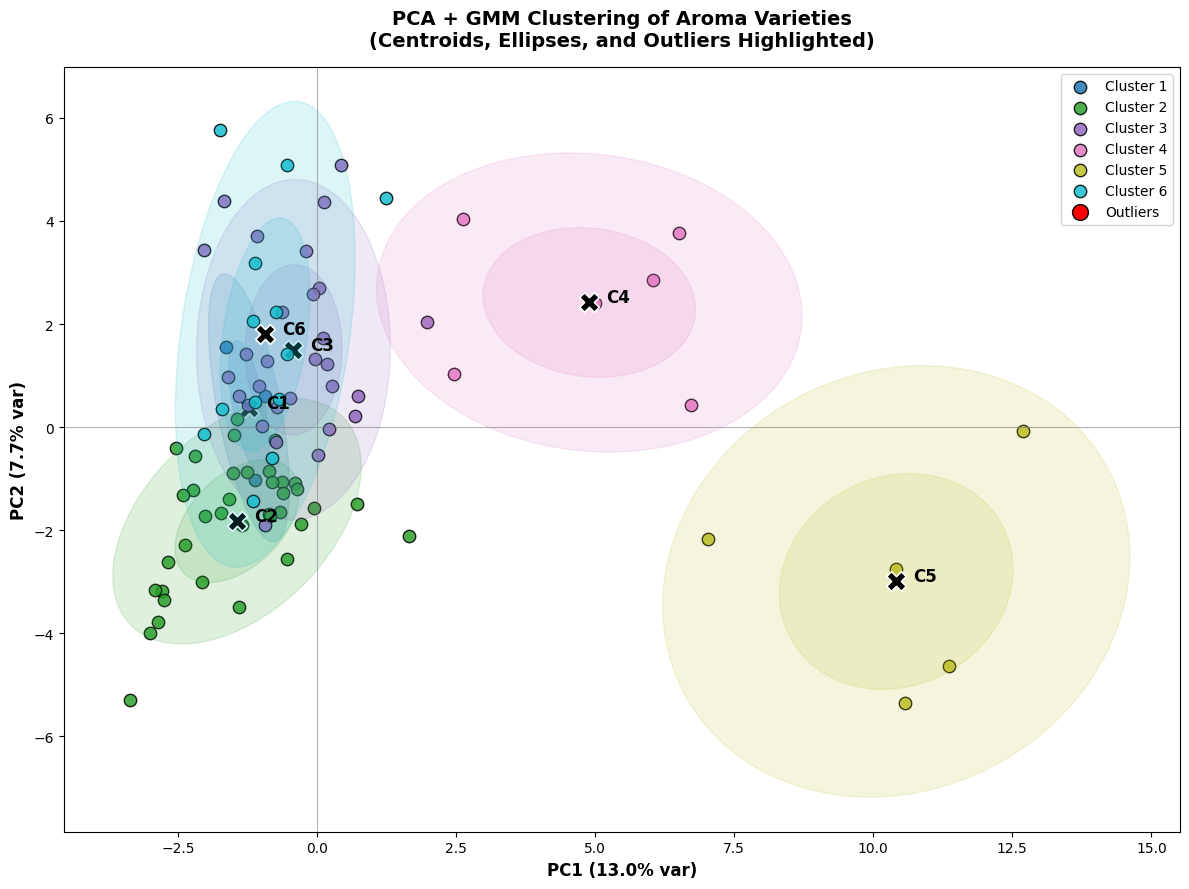

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


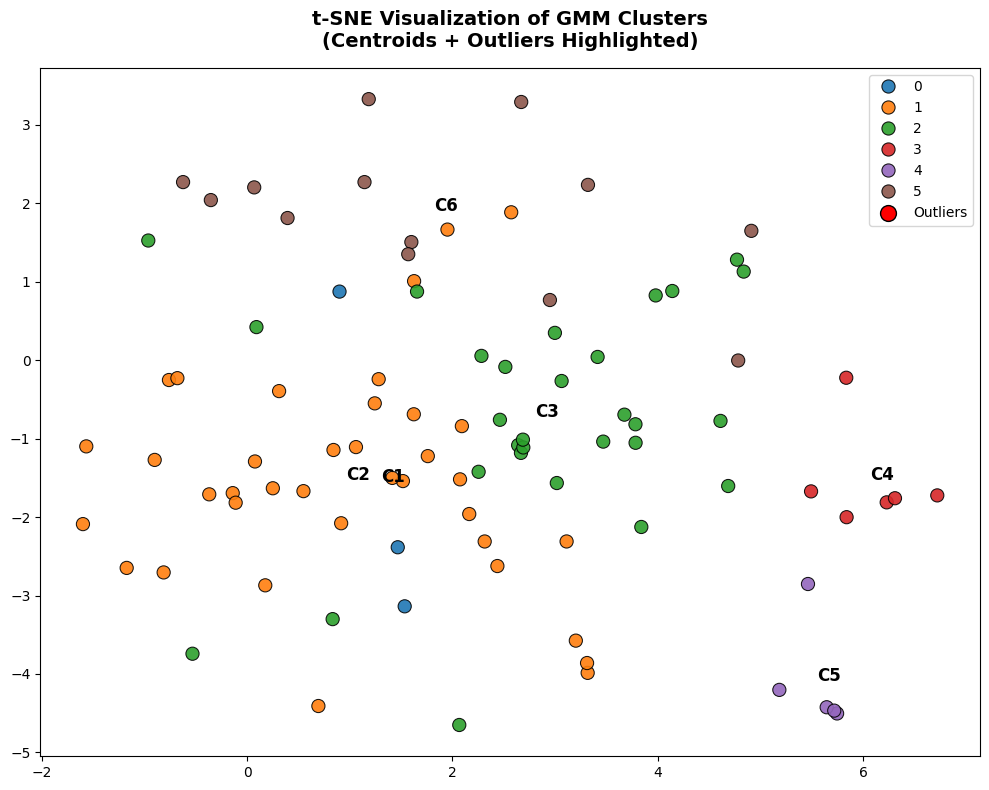


Results saved in: aroma_cluster_results


In [55]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import analyze_aroma_clusters_gmm
# --- Run function ---
results, cluster_means = analyze_aroma_clusters_gmm(aroma_matrix)


# Comparative Analysis of Aroma Compound Classes Between Outlier and Inlier Potato Varieties

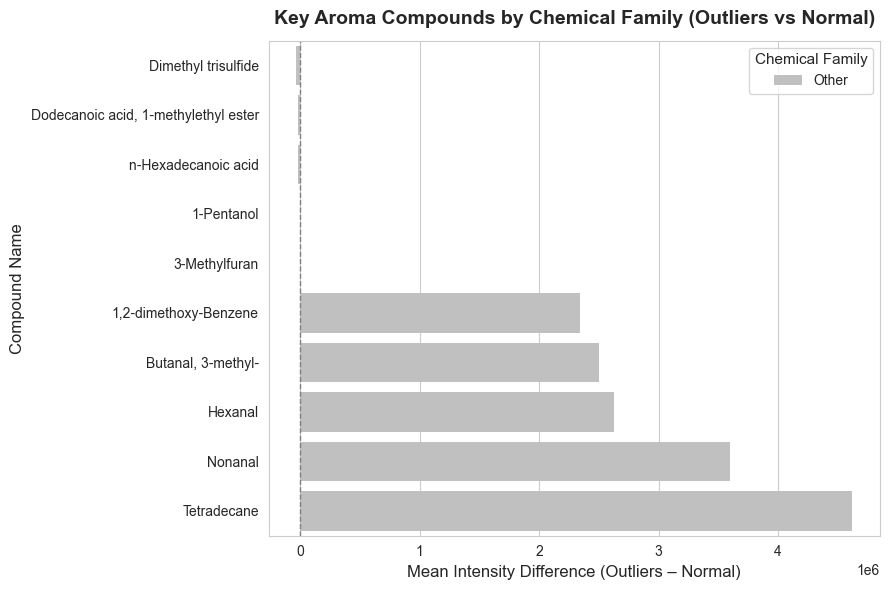

Saved: aroma_cluster_results\outlier_vs_normal_aromas.png


In [ ]:
# import compound_analysis_module
# importlib.reload(compound_analysis_module)
# from compound_analysis_module import plot_outlier_vs_normal_aromas



# top_diff, mean_profiles = plot_outlier_vs_normal_aromas(
#     aroma_matrix=aroma_sample_df,   # ✅ بهتره ماتریس باشه نه aroma_sample_df
#     outliers=['ALTURAS','ANIVIA','DONALD','VIOLET QUEEN'],
#     chemical_family_map=None               # یا CHEMICAL_FAMILY_MAP (dict)
# )



#  Major Contributing Aroma Compounds (Mean Intensity-Based Ranking)


 Total compounds analyzed: 74
 Top 10 aroma compounds by average intensity:

                                  mean         std
2-Propanone, 1-methoxy-     7320592.40  5366590.96
Butanal, 3-methyl-          3065885.93  2259630.46
Acetophenone                2683580.32  3471248.16
Dimethyl disulfide          2119457.86  1227494.45
Hexadecane                  1080866.26  2034542.67
2,3-Butanedione             1073045.57  1267990.69
Dodecanoic acid             1021498.91   826648.45
Furan, 2-pentyl-             945202.27   729342.22
Acetic acid, ethenyl ester   810469.95  1436031.21
Dimethyl phthalate           803755.81  1289233.06


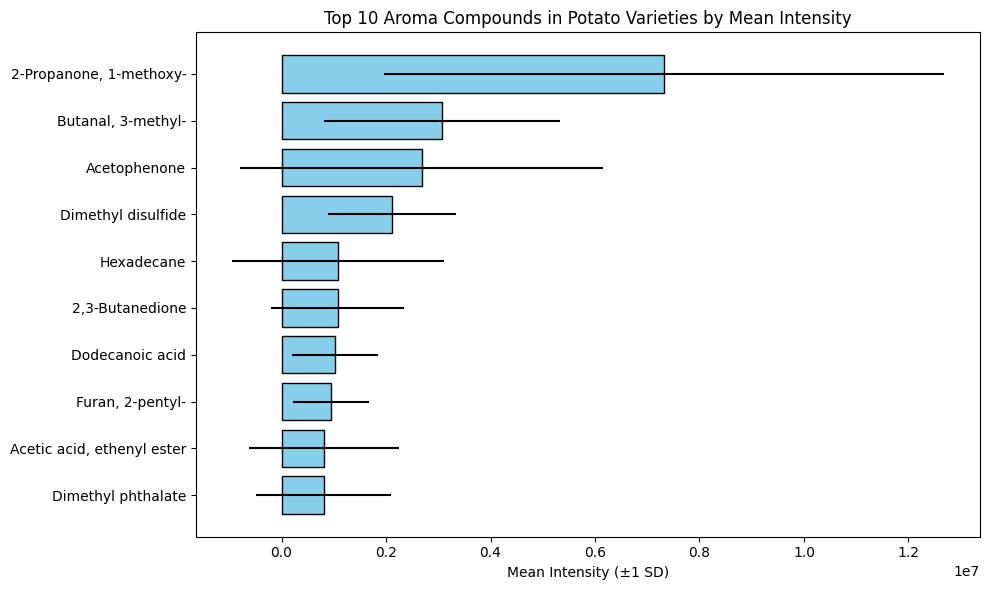

In [56]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_aroma_intensities

desc_stats, top_compounds = summarize_aroma_intensities(aroma_matrix, top_n=10)

# Heatmap of Top Aroma Compounds in Potato Varieties

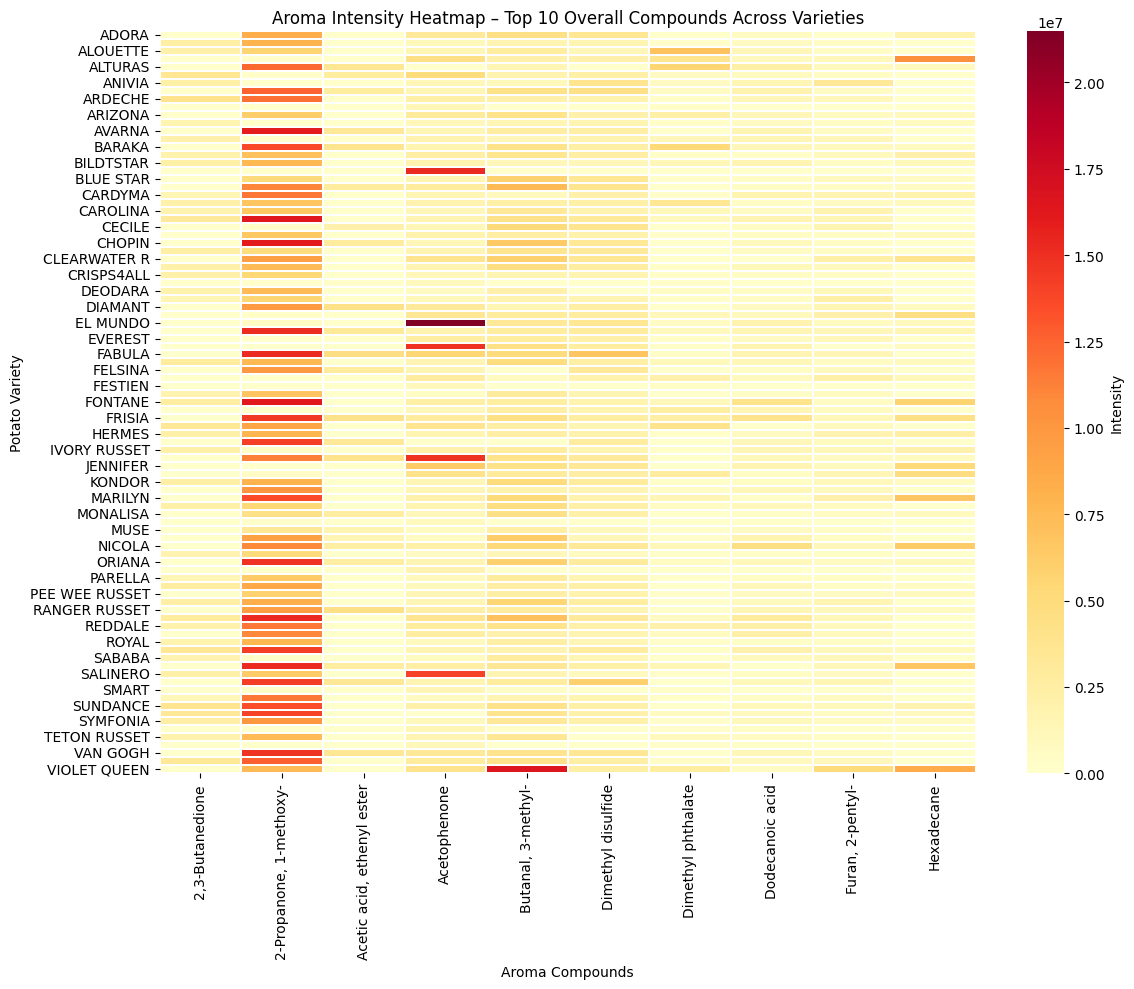

Compound,"2,3-Butanedione","2-Propanone, 1-methoxy-","Acetic acid, ethenyl ester",Acetophenone,"Butanal, 3-methyl-",Dimethyl disulfide,Dimethyl phthalate,Dodecanoic acid,"Furan, 2-pentyl-",Hexadecane
Variety,,,,,,,,,,
ADORA,0.000000e+00,8.268075e+06,0.000000e+00,3.039808e+06,4.342225e+06,3.500004e+06,0.000000e+00,6.654741e+05,0.000000e+00,1.825951e+06
AGRIA,2.378290e+06,7.889641e+06,0.000000e+00,1.016340e+06,1.673090e+06,1.516528e+06,1.294319e+05,6.748774e+05,4.971488e+05,0.000000e+00
ALOUETTE,2.148962e+06,5.672552e+06,0.000000e+00,1.445843e+06,2.759678e+06,1.247146e+06,6.895696e+06,1.230146e+06,4.820290e+05,0.000000e+00
ALTHEA,0.000000e+00,9.310880e+04,0.000000e+00,4.343553e+06,2.073696e+06,2.016362e+06,3.770753e+06,9.703989e+05,1.150555e+06,1.034294e+07
ALTURAS,0.000000e+00,1.222093e+07,3.593850e+06,0.000000e+00,1.495736e+06,0.000000e+00,5.503010e+06,2.285923e+06,9.089799e+05,8.693102e+05
...,...,...,...,...,...,...,...,...,...,...
TETON RUSSET,1.932632e+06,7.386411e+06,0.000000e+00,1.604525e+06,3.588553e+06,0.000000e+00,8.933004e+05,6.651888e+05,5.358491e+05,7.944537e+04
TRIPLE7,0.000000e+00,0.000000e+00,0.000000e+00,1.141913e+06,0.000000e+00,0.000000e+00,1.346633e+05,2.983711e+05,0.000000e+00,0.000000e+00
VAN GOGH,0.000000e+00,1.485115e+07,3.546951e+06,3.233605e+06,3.898049e+06,3.522898e+06,0.000000e+00,1.321344e+06,8.364686e+05,0.000000e+00


In [57]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_top_aroma_heatmap

# Show top 10 compounds overall across varieties
plot_top_aroma_heatmap(aroma_matrix, top_n=10, mode="overall")

# Interactive Aroma Compound Dashboard for Potato Varieties

In [58]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import launch_aroma_dashboard
launch_aroma_dashboard()


TypeError: launch_aroma_dashboard() missing 1 required positional argument: 'aroma_matrix'

# Feature Importance Analysis of Aroma Compounds Using PCA Loadings

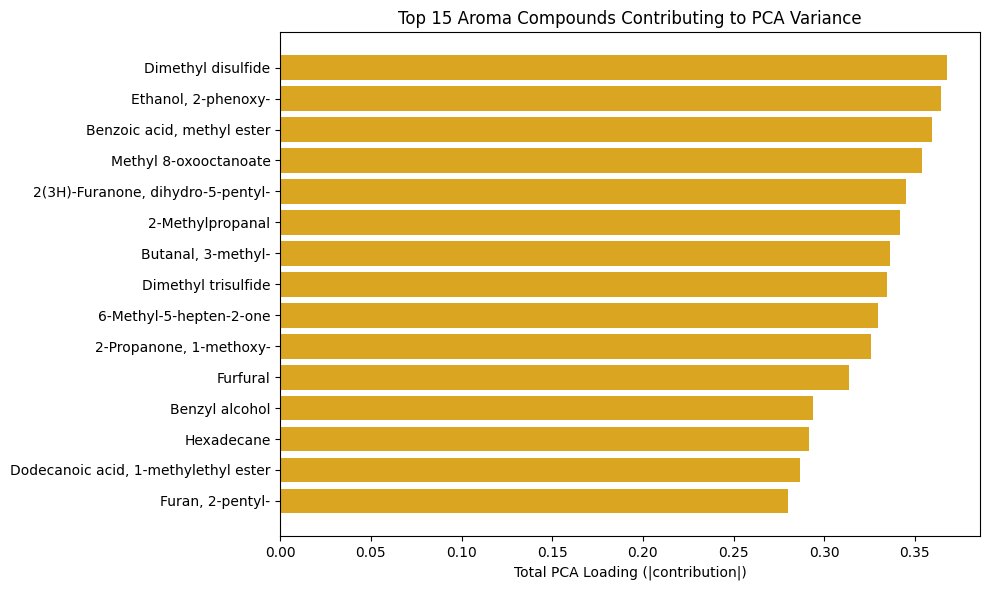

 Top 15 most contributing compounds:
                                           PC1       PC2  Total_Importance
Dimethyl disulfide                    0.068976  0.298571          0.367548
Ethanol, 2-phenoxy-                   0.258180  0.106184          0.364364
Benzoic acid, methyl ester            0.279294  0.080042          0.359336
Methyl 8-oxooctanoate                 0.247547  0.106274          0.353821
2(3H)-Furanone, dihydro-5-pentyl-     0.287796  0.057454          0.345250
2-Methylpropanal                      0.008493  0.333412          0.341905
Butanal, 3-methyl-                    0.136344  0.199980          0.336324
Dimethyl trisulfide                   0.042228  0.292481          0.334709
6-Methyl-5-hepten-2-one               0.169663  0.160187          0.329851
2-Propanone, 1-methoxy-               0.024830  0.301210          0.326040
Furfural                              0.044745  0.268949          0.313694
Benzyl alcohol                        0.264562  0.029263       

In [59]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import compute_feature_importance_from_pca
importance_df = compute_feature_importance_from_pca(aroma_matrix)


# Joining the sensory panel data 

In [60]:

# --- Load configuration ---
with open(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Read the sensory Excel file using config path ---
sensory_path = config["paths"]["sensory_data"]
sensory = pd.read_excel(sensory_path)

# --- Print column names and preview the first few rows ---
print("Columns:", list(sensory.columns))
display(sensory.head(config["settings"]["display_rows"]))


Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, clus

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Sensory Panel Data Processing

In [61]:

import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_sensory_traits

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = summarize_sensory_traits(sensory, sensory_cols)

 Rows (unique varieties): 59
 Traits averaged: 20

 Example of summarized sensory data:
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  ...  Sweet Aftertaste  \
0          

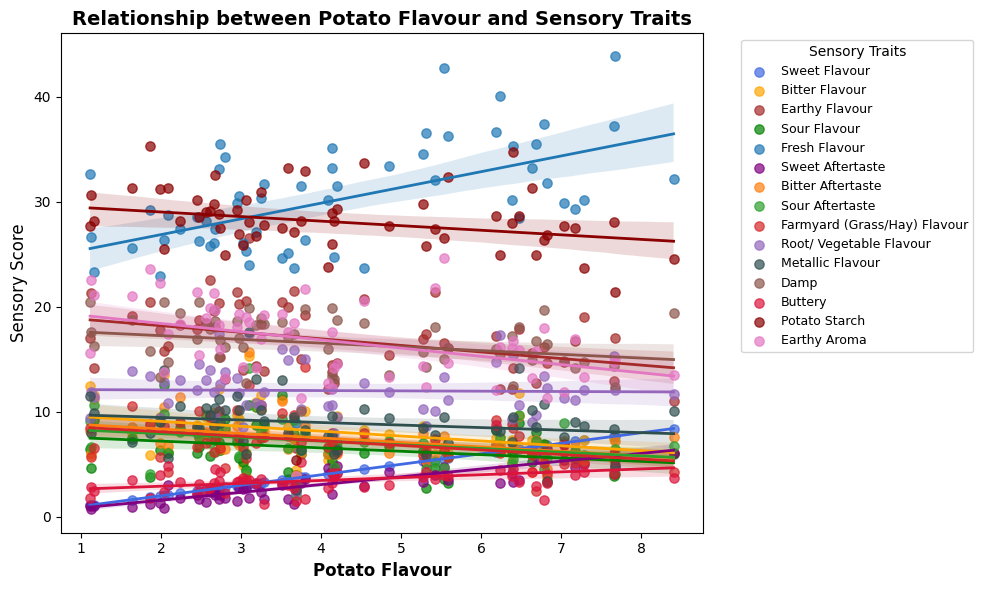

In [62]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_sensory_vs_flavour

plot_sensory_vs_flavour(sensory_summary, base_trait="SWEET FLAVOUR")


# Predicting the flavors for all the non existing varaieties by using the aroma compounds

# First merge aroma and sensory datasets

In [63]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import merge_aroma_with_sensory


merged_aroma_sensory, common = merge_aroma_with_sensory(aroma_matrix, sensory_summary)



Varieties in Aroma Data   : 93
Varieties in Sensory Data : 59
Common varieties          : 20
Merged varieties          : 20
Merged shape              : (20, 95)


,Variety,(E)-2-Decenal,"(E, Z)-2,4-Decadienal","1-Hexanol, 2-ethyl-",1-Nonanol,1-Octen-3-ol,1-Octyn-3-ol,"2(3H)-Furanone, dihydro-5-pentyl-","2,3-Butanedione","2,3-Pentanedione",...,Sweet Aftertaste,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Potato Starch,Metalic
0,ADORA,0.0,0.0000,451522.469996,0.0,0.000000,0.000000,407818.714969,0.000000e+00,0.0,...,1.790,18.537,15.953,4.385,21.588,19.845,3.491,29.071,28.018,16.498
1,AGRIA,0.0,0.0000,0.000000,0.0,0.000000,84727.888765,165450.129810,2.378290e+06,0.0,...,1.203,23.580,12.801,3.298,23.219,15.823,1.752,26.592,35.300,9.280
2,BERBER,0.0,181974.7306,601169.684054,0.0,0.000000,0.000000,754606.387431,1.947668e+06,0.0,...,3.355,16.732,10.866,7.146,24.719,12.410,4.535,31.505,34.713,7.520
3,BILDTSTAR,0.0,0.0000,0.000000,0.0,0.000000,0.000000,328922.259507,2.331200e+06,0.0,...,0.756,22.512,16.668,2.590,21.487,17.625,2.791,24.566,30.645,7.869
4,BINTJE,0.0,0.0000,0.000000,0.0,136927.151245,0.000000,68924.976054,0.000000e+00,0.0,...,3.506,14.671,10.804,7.408,19.260,16.103,3.859,29.521,32.350,6.301


Found 65 aroma compounds and 20 sensory traits.
Displaying 65 compounds (threshold=0.2).


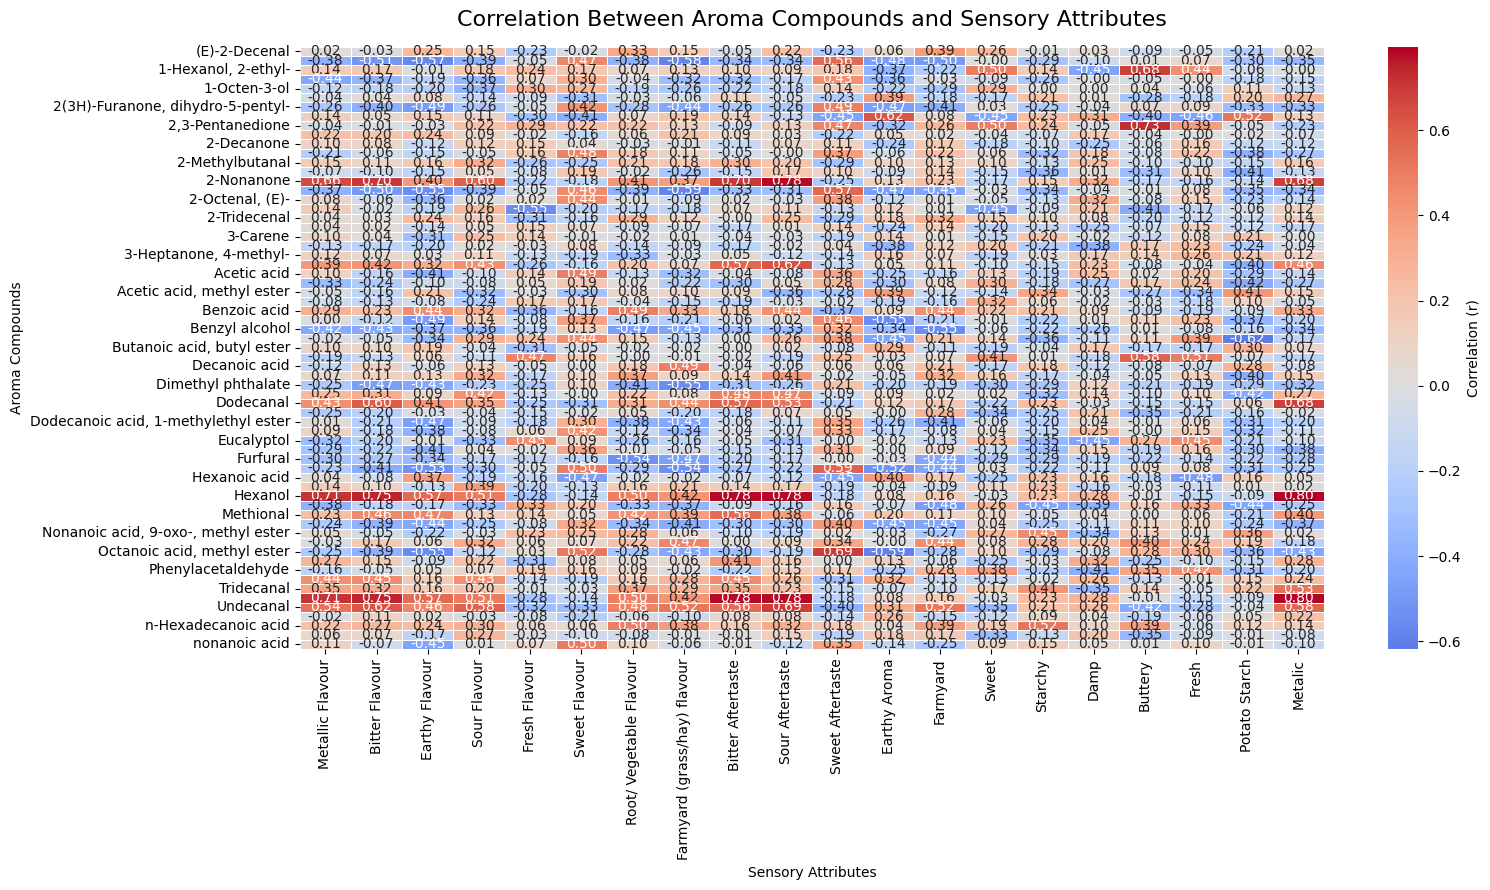

Correlation matrix saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/aroma_sensory_corr_output.csv


In [64]:
import yaml
import importlib
import compound_analysis_module
from compound_analysis_module import plot_aroma_sensory_correlation

# Reload if working interactively
importlib.reload(compound_analysis_module)

# --- Load config ---
with open(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\config.yaml",
    "r"
) as f:
    config = yaml.safe_load(f)

# --- Define sensory columns (still explicit; they stay the same) ---
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
    "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
    "Damp","Buttery","Fresh","Potato Starch","Metalic"
]

corr_result = plot_aroma_sensory_correlation(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=sensory_cols,
    aroma_descriptions=None,  
    threshold=config["settings"]["correlation_threshold"],
    min_compounds=config["settings"]["min_compounds"],
    save_path=config["paths"]["aroma_sensory_corr_output"]
)



# Sensory prediction based on aroma compounds using multiple models.

# PLSR MOdel + MAF score

['Variety', '(E)-2-Decenal', '(E, Z)-2,4-Decadienal', '1-Hexanol, 2-ethyl-', '1-Nonanol', '1-Octen-3-ol', '1-Octyn-3-ol', '2(3H)-Furanone, dihydro-5-pentyl-', '2,3-Butanedione', '2,3-Pentanedione', '2,4-Nonadienal', '2-Decanone', '2-Ethylfuran', '2-Heptenal', '2-Methylbutanal', '2-Methylpropanal', '2-Nonanone', '2-Nonenal, (E)-', '2-Octenal, (E)-', '2-Propanone, 1-methoxy-', '2-Tridecenal', '2-Undecenal', '3,5-Octadien-2-one', '3-Carene', '3-Furaldehyde', '3-Heptanone', '3-Heptanone, 4-methyl-', '3-Methylfuran', '3-Octanone', '6-Methyl-5-hepten-2-one', 'Acetic acid', 'Acetic acid, ethenyl ester', 'Acetic acid, methyl ester', 'Acetophenone', 'Benzoic acid', 'Benzoic acid, methyl ester', 'Benzyl alcohol', 'Butanal, 3-methyl-', 'Butanoic acid', 'Butanoic acid, butyl ester', 'Decanal', 'Decanoic acid', 'Dimethyl disulfide', 'Dimethyl phthalate', 'Dimethyl sulfide', 'Dimethyl trisulfide', 'Dodecanal', 'Dodecanoic acid', 'Dodecanoic acid, 1-methylethyl ester', 'Ethanol, 2-phenoxy-', 'Eucalyp

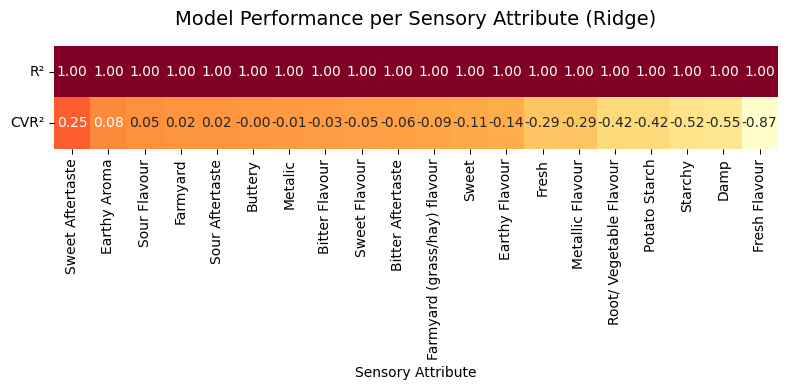

Training with 20 samples, 65 aroma features, and 20 sensory traits.

Fitting model: Linear

Cross-validated performance summary:
               Sensory Attribute   R²      CVR²
10              Sweet Aftertaste  1.0  0.249864
11                  Earthy Aroma  1.0  0.072503
3                   Sour Flavour  1.0  0.047747
12                      Farmyard  1.0  0.017176
9                Sour Aftertaste  1.0  0.014754
16                       Buttery  1.0 -0.002766
19                       Metalic  1.0 -0.013530
1                 Bitter Flavour  1.0 -0.029587
5                  Sweet Flavour  1.0 -0.048169
8              Bitter Aftertaste  1.0 -0.059669
7   Farmyard (grass/hay) flavour  1.0 -0.091927
13                         Sweet  1.0 -0.109884
2                 Earthy Flavour  1.0 -0.142448
17                         Fresh  1.0 -0.290144
0               Metallic Flavour  1.0 -0.290481
6        Root/ Vegetable Flavour  1.0 -0.423242
18                 Potato Starch  1.0 -0.434331
14     

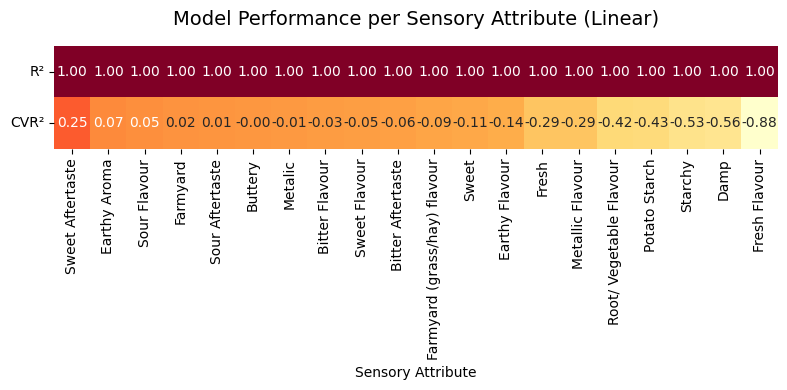

Training with 20 samples, 65 aroma features, and 20 sensory traits.

Fitting model: ElasticNet

Cross-validated performance summary:
               Sensory Attribute        R²      CVR²
11                  Earthy Aroma  0.524258  0.172988
18                 Potato Starch  0.545182  0.109151
1                 Bitter Flavour  0.636529  0.044679
16                       Buttery  0.634204  0.034671
10              Sweet Aftertaste  0.560151 -0.000305
12                      Farmyard  0.510538 -0.020923
9                Sour Aftertaste  0.638542 -0.038981
0               Metallic Flavour  0.606344 -0.039126
19                       Metalic  0.611885 -0.044339
8              Bitter Aftertaste  0.623871 -0.062598
2                 Earthy Flavour  0.557934 -0.067774
3                   Sour Flavour  0.498696 -0.071976
7   Farmyard (grass/hay) flavour  0.531937 -0.104489
14                       Starchy  0.438912 -0.141541
5                  Sweet Flavour  0.443840 -0.154432
6        Root/ Vege

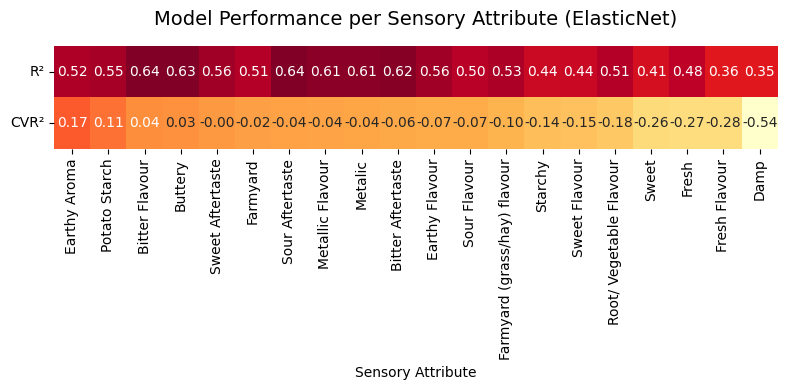

Training with 20 samples, 65 aroma features, and 20 sensory traits.

Fitting model: PLSR

Cross-validated performance summary:
               Sensory Attribute        R²      CVR²
2                 Earthy Flavour  0.612808 -0.251930
19                       Metalic  0.733761 -0.430960
7   Farmyard (grass/hay) flavour  0.548773 -0.441891
10              Sweet Aftertaste  0.761959 -0.444827
1                 Bitter Flavour  0.749257 -0.483882
12                      Farmyard  0.264979 -0.484038
11                  Earthy Aroma  0.711123 -0.534040
8              Bitter Aftertaste  0.724332 -0.624386
18                 Potato Starch  0.467906 -0.648574
3                   Sour Flavour  0.622718 -0.705410
9                Sour Aftertaste  0.809773 -0.744557
0               Metallic Flavour  0.657663 -0.861394
6        Root/ Vegetable Flavour  0.505084 -0.908485
5                  Sweet Flavour  0.671605 -0.973315
14                       Starchy  0.213863 -1.077729
13                       

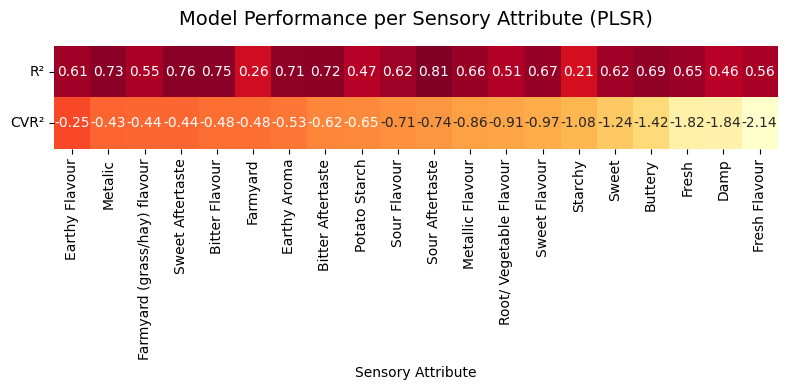

In [66]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import predict_sensory_from_models

print(merged_aroma_sensory.columns.tolist())

predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_matrix,
    sensory_cols=sensory_cols,
    model_type="Ridge",  # Try: 'Linear', 'Lasso', 'ElasticNet', or 'PLSR'
    n_components=3,
    cv_folds=5,
    alpha=0.5
)
predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_matrix,
    sensory_cols=sensory_cols,
    model_type='Linear',  # Try: 'Linear', 'Lasso', 'ElasticNet', or 'PLSR'
    n_components=3,
    cv_folds=5,
    alpha=0.5
)


predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_matrix,
    sensory_cols=sensory_cols,
    model_type='ElasticNet', 
    n_components=3,
    cv_folds=5,
    alpha=0.5
)



predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_matrix,
    sensory_cols=sensory_cols,
    model_type='PLSR',  
    n_components=3,
    cv_folds=5,
    alpha=0.5
)


# Non linear model 


Model Performance Summary (R² and CVR²):
                    metallic flavour  bitter flavour  earthy flavour  \
R²   Random Forest              0.85            0.88            0.84   
     Extra Trees                1.00            1.00            1.00   
     XGBoost                    1.00            1.00            1.00   
     SVR (RBF)                  0.69            0.66            0.81   
CVR² Random Forest             -0.38           -0.06           -0.11   
     Extra Trees               -0.46           -0.00           -0.42   
     XGBoost                   -1.88           -1.52           -0.43   
     SVR (RBF)                 -0.03            0.00            0.01   

                    sour flavour  fresh flavour  sweet flavour  \
R²   Random Forest          0.86           0.82           0.83   
     Extra Trees            1.00           1.00           1.00   
     XGBoost                1.00           1.00           1.00   
     SVR (RBF)              0.85           0.

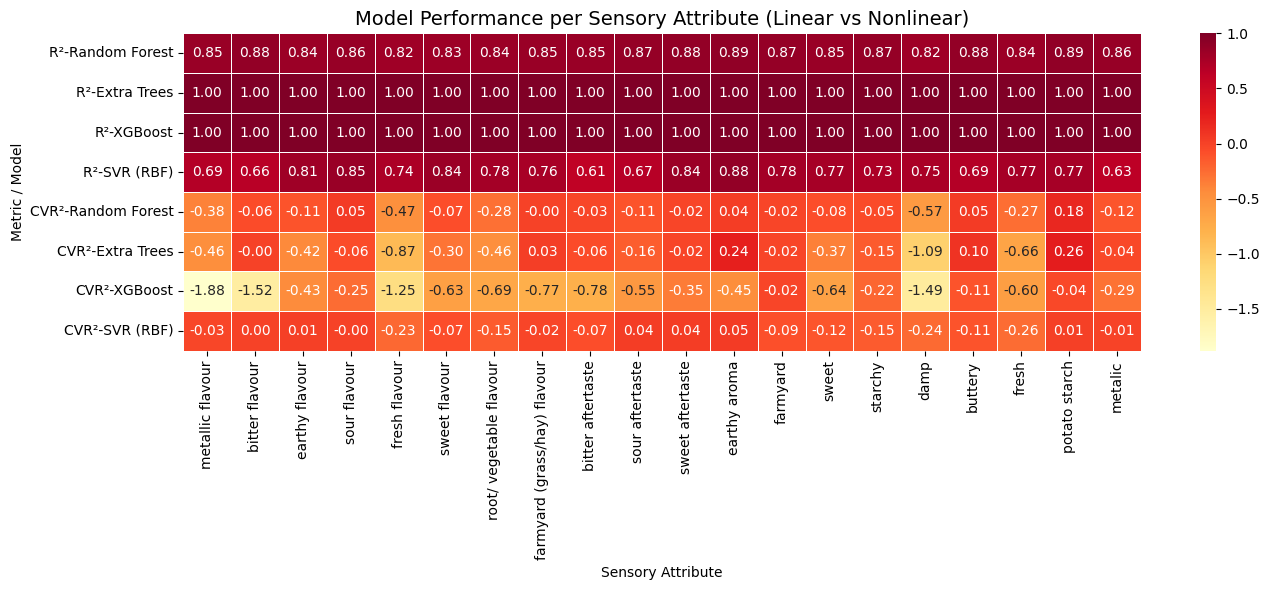

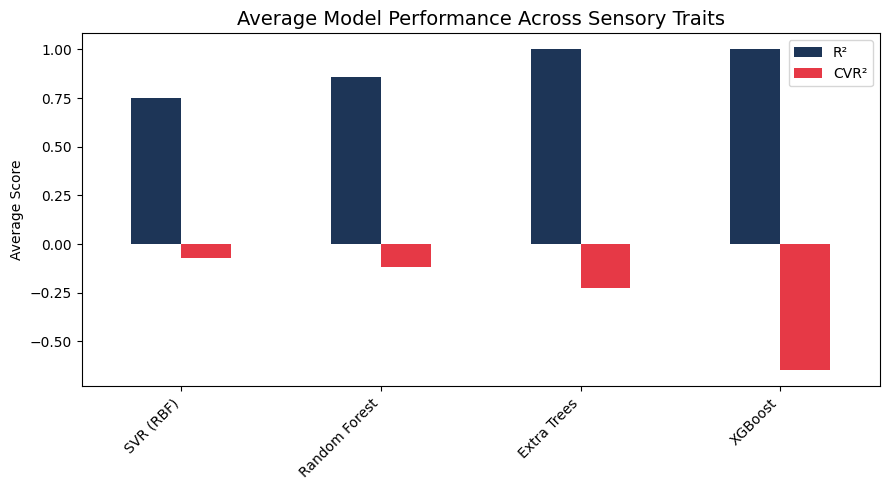

In [67]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import  predict_sensory_with_models_and_cvr2

r2_df, cvr2_df, summary = predict_sensory_with_models_and_cvr2(
    merged_aroma_sensory=merged_aroma_sensory,
    aroma_matrix=aroma_matrix,
    sensory_cols=sensory_cols,
    n_estimators=300,     # number of trees for RF / ExtraTrees
    n_components=3,       # number of latent components for PLSR
    cv_folds=5            # 5-fold cross validation
)



# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA

Varieties total (aroma): 94
Panel varieties (sensory present): 20
Non-panel varieties (sensory missing): 74

PCA explained variance ratio: [0.449 0.194 0.089]
Total projected varieties: 94


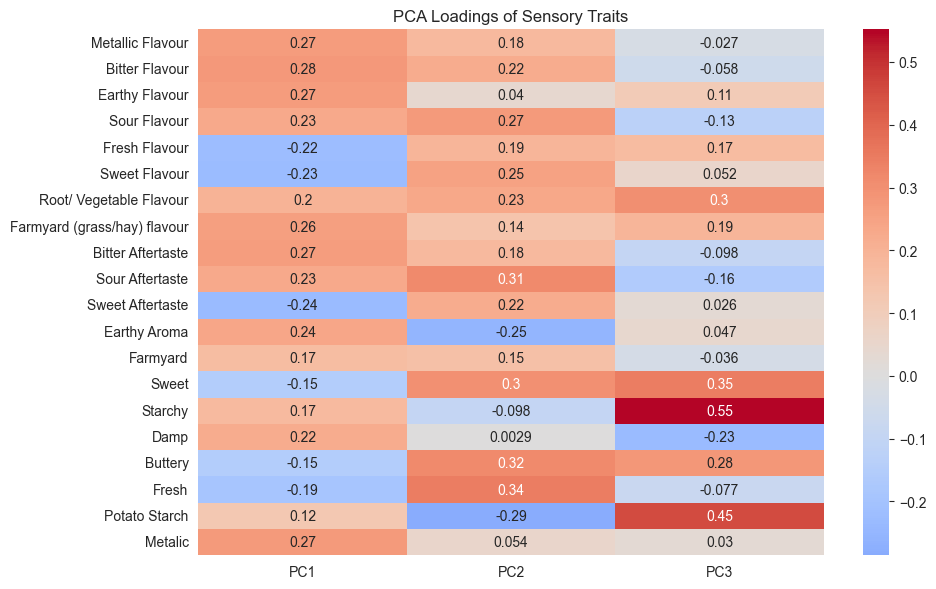

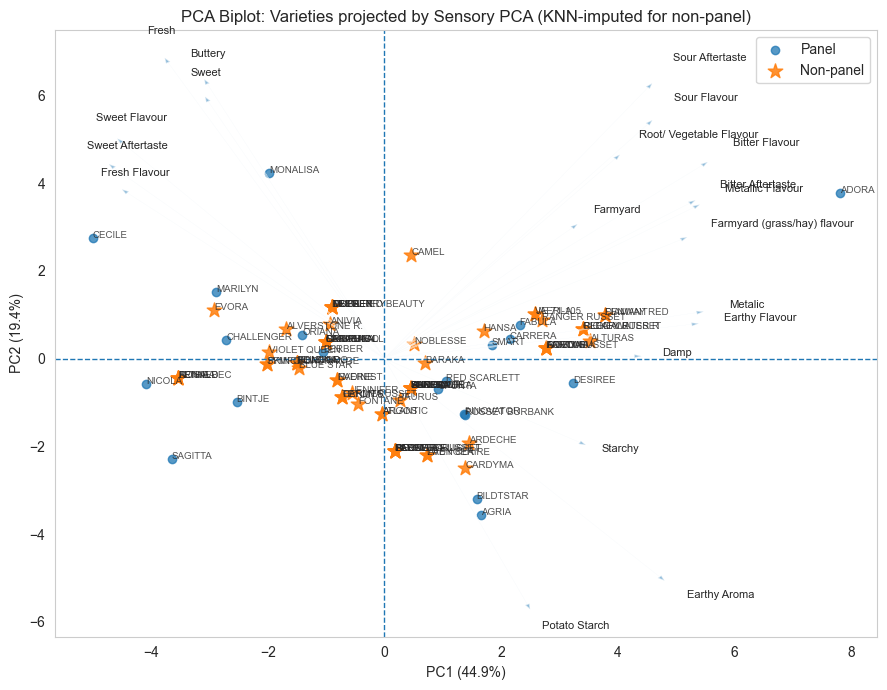

Projection saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/sensory_pca_projection_knn.csv
Loadings saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_loadings.csv
Files saved:
- C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/sensory_pca_projection_knn.csv
- C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_loadings.csv
- C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/pc_df.csv


In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import perform_knn_sensory_projection


# --- Load config ---
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Access paths from config ---
projection_path = config["paths"]["sensory_pca_projection_knn"]
loadings_path = config["paths"]["sensory_pca_loadings"]
pc_df_path = config["paths"]["sensory_pca_pc_df"]

# --- Run the function using paths from config ---
pc_df, pca, loadings_df = perform_knn_sensory_projection(
    aroma_matrix=aroma_sample_df,      # همون ماتریس 94×95 با index=Variety هم اوکیه
    sensory_summary=sensory_summary,   # دیتای پنل
    k=3,
    n_components=3,
    scaling_factor=20,
    save_projection_path=projection_path,
    save_loadings_path=loadings_path
)

pc_df.to_csv(pc_df_path, index=False)
print(f"Files saved:\n- {projection_path}\n- {loadings_path}\n- {pc_df_path}")



In [ ]:

import importlib
import yaml
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import perform_knn_sensory_projection_rotatable_3D

# --- Load YAML configuration ---
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Extract values ---
paths = config["paths"]
params = config["parameters"]

# --- Run the 3D projection function using config values ---
pc_df, pca_model, loadings_df = perform_knn_sensory_projection_rotatable_3D(
    aroma_matrix=aroma_sample_df,
    sensory_summary=sensory_summary,
    rotation_angle_12=params["rotation_angle_12"],
    rotation_angle_13=params["rotation_angle_13"],
    rotation_angle_23=params["rotation_angle_23"],
    scaling_factor=params["scaling_factor"],
    loading_threshold=params["loading_threshold"],
    save_projection_path=paths["sensory_pca_projection"],
    save_loadings_path=paths["sensory_pca_loadings"]
)

#confirm and save dataframe 
pc_df.to_csv(paths["sensory_pca_projection"], index=False)
loadings_df.to_csv(paths["sensory_pca_loadings"], index=False)

print(" Projection and loadings saved:")
print(f"• Projection → {paths['sensory_pca_projection']}")
print(f"• Loadings   → {paths['sensory_pca_loadings']}")


KeyError: 'rotation_angle_12'

# PCA-Based Sensory Profile Summary of Potato Varieties

In [ ]:
# import importlib
# import yaml
# import compound_analysis_module
# importlib.reload(compound_analysis_module)
# from compound_analysis_module import interpret_variety_sensory_profile

# # --- Load from config ---
# with open("config.yaml", "r") as f:
#     config = yaml.safe_load(f)

# interp_cfg = config["interpretation"]

# # --- Run function using config values ---
# summary_df = interpret_variety_sensory_profile(
#     pc_df=pc_df,
#     pc1_thresh=interp_cfg["pc1_thresh"],
#     pc2_thresh=interp_cfg["pc2_thresh"],
#     save_path=interp_cfg["save_path"]
# )

# print(" Variety sensory summary saved to:")
# print(interp_cfg["save_path"])


ImportError: cannot import name 'interpret_variety_sensory_profile' from 'compound_analysis_module' (c:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\compound_analysis_module.py)

In [ ]:
# def perform_knn_sensory_projection_rotatable(
#     aroma_matrix,
#     sensory_summary,
#     k=3,
#     n_components=3,
#     scaling_factor=4,
#     loading_threshold=0.2,
#     rotation_angle_12=0,     # rotation for PC1–PC2
#     rotation_angle_13=0,     # rotation for PC1–PC3
#     save_projection_path=None,
#     save_loadings_path=None
# ):
#     """
#     Merge aroma + sensory data, impute missing sensory traits using KNN,
#     perform PCA on sensory traits, visualize projection (PC1–PC2 and PC1–PC3)
#     with independent rotation controls, loadings heatmap, and biplots.
#     """

#     # --- Step 1: Standardize column names ---
#     aroma_matrix = aroma_matrix.copy()
#     sensory_summary = sensory_summary.copy()
#     aroma_matrix.columns = aroma_matrix.columns.str.strip().str.upper()
#     sensory_summary.columns = sensory_summary.columns.str.strip().str.upper()

#     # --- Step 2: Check for Variety column ---
#     if "VARIETY" not in aroma_matrix.columns:
#         raise KeyError("'VARIETY' column not found in aroma_matrix!")
#     if "VARIETY" not in sensory_summary.columns:
#         raise KeyError("'VARIETY' column not found in sensory_summary!")

#     # --- Step 3: Merge datasets ---
#     merged = aroma_matrix.merge(sensory_summary, on="VARIETY", how="left")
#     merged["IS_PANEL"] = merged["VARIETY"].isin(sensory_summary["VARIETY"])

#     panel_df = merged[merged["IS_PANEL"]].reset_index(drop=True)
#     nonpanel_df = merged[~merged["IS_PANEL"]].reset_index(drop=True)

#     sensory_cols = [c for c in sensory_summary.columns if c != "VARIETY"]
#     aroma_cols = [c for c in aroma_matrix.columns if c != "VARIETY"]

#     Y_panel = panel_df[sensory_cols].fillna(0)
#     X_panel = panel_df[aroma_cols].fillna(0)
#     X_nonpanel = nonpanel_df[aroma_cols].fillna(0)

#     # --- Step 4: KNN imputation ---
#     nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
#     nn.fit(X_panel)
#     distances, indices = nn.kneighbors(X_nonpanel)
#     Y_nonpanel_pred = np.array([Y_panel.iloc[idx].mean(axis=0) for idx in indices])

#     # --- Step 5: PCA ---
#     scaler = StandardScaler().fit(Y_panel.values)
#     X_panel_scaled = scaler.transform(Y_panel.values)
#     X_nonpanel_scaled = scaler.transform(Y_nonpanel_pred)

#     pca = PCA(n_components=n_components, random_state=0)
#     pcs_panel = pca.fit_transform(X_panel_scaled)
#     pcs_nonpanel = pca.transform(X_nonpanel_scaled)

#     panel_pcs = pd.DataFrame(pcs_panel, columns=[f"PC{i+1}" for i in range(n_components)])
#     panel_pcs["Variety"] = panel_df["VARIETY"].values
#     panel_pcs["is_panel"] = True

#     nonpanel_pcs = pd.DataFrame(pcs_nonpanel, columns=[f"PC{i+1}" for i in range(n_components)])
#     nonpanel_pcs["Variety"] = nonpanel_df["VARIETY"].values
#     nonpanel_pcs["is_panel"] = False

#     pc_df = pd.concat([panel_pcs, nonpanel_pcs], ignore_index=True)

#     loadings_df = pd.DataFrame(
#         pca.components_.T,
#         columns=[f"PC{i+1}" for i in range(n_components)],
#         index=sensory_cols
#     )

#     print("\nPCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

#     # --- Step 6: Separate rotations ---
#     theta12 = np.deg2rad(rotation_angle_12)
#     theta13 = np.deg2rad(rotation_angle_13)

#     rot12 = np.array([[np.cos(theta12), -np.sin(theta12)],
#                       [np.sin(theta12),  np.cos(theta12)]])
#     rot13 = np.array([[np.cos(theta13), -np.sin(theta13)],
#                       [np.sin(theta13),  np.cos(theta13)]])

#     rotated_scores_12 = pc_df[["PC1", "PC2"]].values @ rot12
#     rotated_loadings_12 = loadings_df[["PC1", "PC2"]].values @ rot12
#     pc_df["PC1_rot12"], pc_df["PC2_rot12"] = rotated_scores_12[:, 0], rotated_scores_12[:, 1]
#     loadings_df["PC1_rot12"], loadings_df["PC2_rot12"] = rotated_loadings_12[:, 0], rotated_loadings_12[:, 1]

#     rotated_scores_13 = pc_df[["PC1", "PC3"]].values @ rot13
#     rotated_loadings_13 = loadings_df[["PC1", "PC3"]].values @ rot13
#     pc_df["PC1_rot13"], pc_df["PC3_rot13"] = rotated_scores_13[:, 0], rotated_scores_13[:, 1]
#     loadings_df["PC1_rot13"], loadings_df["PC3_rot13"] = rotated_loadings_13[:, 0], rotated_loadings_13[:, 1]

#     # --- Step 7: Loadings heatmap ---
#     plt.figure(figsize=(10, 6))
#     sns.heatmap(loadings_df[["PC1", "PC2", "PC3"]], annot=True, cmap="coolwarm", center=0)
#     plt.title("PCA Loadings of Sensory Traits (Before Rotation)")
#     plt.grid(False)
#     plt.tight_layout()
#     plt.show()

#     # --- Step 8: Rotated PC1–PC2 Biplot (no gridlines) ---
#     plt.figure(figsize=(8, 7))
#     plt.scatter(pc_df.loc[pc_df["is_panel"], "PC1_rot12"],
#                 pc_df.loc[pc_df["is_panel"], "PC2_rot12"],
#                 c="blue", label="Panel", alpha=0.7)
#     plt.scatter(pc_df.loc[~pc_df["is_panel"], "PC1_rot12"],
#                 pc_df.loc[~pc_df["is_panel"], "PC2_rot12"],
#                 c="orange", marker="*", s=120, label="Non-panel")

#     for i, row in pc_df.iterrows():
#         if row["is_panel"]:
#             plt.text(row["PC1_rot12"], row["PC2_rot12"], row["Variety"], fontsize=7)

#     strong_features_12 = loadings_df[
#         (loadings_df["PC1"].abs() > loading_threshold) |
#         (loadings_df["PC2"].abs() > loading_threshold)
#     ]

#     for feature in strong_features_12.index:
#         x = loadings_df.loc[feature, "PC1_rot12"] * scaling_factor
#         y = loadings_df.loc[feature, "PC2_rot12"] * scaling_factor
#         plt.arrow(0, 0, x, y, color="red", alpha=0.6, head_width=0.08, length_includes_head=True)
#         plt.text(x * 1.1, y * 1.1, feature, color="red", fontsize=8)

#     plt.xlabel("Rotated PC1 (PC1–PC2 plane)")
#     plt.ylabel("Rotated PC2")
#     plt.title(f"PCA Biplot (Rotated {rotation_angle_12}° — PC1 vs PC2)")
#     plt.legend()
#     plt.grid(False)
#     plt.tight_layout()
#     plt.show()

#     # --- Step 9: Rotated PC1–PC3 Biplot (no gridlines) ---
#     plt.figure(figsize=(8, 7))
#     plt.scatter(pc_df.loc[pc_df["is_panel"], "PC1_rot13"],
#                 pc_df.loc[pc_df["is_panel"], "PC3_rot13"],
#                 c="blue", label="Panel", alpha=0.7)
#     plt.scatter(pc_df.loc[~pc_df["is_panel"], "PC1_rot13"],
#                 pc_df.loc[~pc_df["is_panel"], "PC3_rot13"],
#                 c="orange", marker="*", s=120, label="Non-panel")

#     for i, row in pc_df.iterrows():
#         if row["is_panel"]:
#             plt.text(row["PC1_rot13"], row["PC3_rot13"], row["Variety"], fontsize=7)

#     strong_features_13 = loadings_df[
#         (loadings_df["PC1"].abs() > loading_threshold) |
#         (loadings_df["PC3"].abs() > loading_threshold)
#     ]

#     for feature in strong_features_13.index:
#         x = loadings_df.loc[feature, "PC1_rot13"] * scaling_factor
#         y = loadings_df.loc[feature, "PC3_rot13"] * scaling_factor
#         plt.arrow(0, 0, x, y, color="red", alpha=0.6, head_width=0.08, length_includes_head=True)
#         plt.text(x * 1.1, y * 1.1, feature, color="red", fontsize=8)

#     plt.xlabel("Rotated PC1 (PC1–PC3 plane)")
#     plt.ylabel("Rotated PC3")
#     plt.title(f"PCA Biplot (Rotated {rotation_angle_13}° — PC1 vs PC3)")
#     plt.legend()
#     plt.grid(False)
#     plt.tight_layout()
#     plt.show()

#     return pc_df, pca, loadings_df

# pc_df, pca_model, loadings_df = perform_knn_sensory_projection_rotatable(
#     aroma_matrix=aroma_matrix,
#     sensory_summary=sensory_summary,
#     rotation_angle_12=0,   # rotate PC1–PC2 plane 30°
#     rotation_angle_13=0,  # rotate PC1–PC3 plane 180°
#     scaling_factor=15,
#     loading_threshold=0.2
# )


# Sensory pcs interpretation

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import interpret_variety_sensory
# Generate the interpretation table
sensory_profile_table = interpret_variety_sensory(pc_df, loadings_df)
display(sensory_profile_table.head(10))


,Variety,Dominant traits (PC1),Dominant traits (PC2),Dominant traits (PC3)
0,ADORA,"Bitter Flavour, Metalic, Metallic Flavour","Fresh, Buttery, Sour Aftertaste","low Starchy, low Potato Starch, low Sweet"
1,AGRIA,"Bitter Flavour, Metalic, Metallic Flavour","low Fresh, low Buttery, low Sour Aftertaste","Starchy, Potato Starch, Sweet"
2,BERBER,"low Bitter Flavour, low Metalic, low Metallic ...","Fresh, Buttery, Sour Aftertaste","Starchy, Potato Starch, Sweet"
3,BILDTSTAR,"Bitter Flavour, Metalic, Metallic Flavour","low Fresh, low Buttery, low Sour Aftertaste","Starchy, Potato Starch, Sweet"
4,BINTJE,"low Bitter Flavour, low Metalic, low Metallic ...","low Fresh, low Buttery, low Sour Aftertaste","Starchy, Potato Starch, Sweet"
5,CARRERA,"Bitter Flavour, Metalic, Metallic Flavour","Fresh, Buttery, Sour Aftertaste","low Starchy, low Potato Starch, low Sweet"
6,CECILE,"low Bitter Flavour, low Metalic, low Metallic ...","Fresh, Buttery, Sour Aftertaste","low Starchy, low Potato Starch, low Sweet"
7,CHALLENGER,"low Bitter Flavour, low Metalic, low Metallic ...","Fresh, Buttery, Sour Aftertaste","Starchy, Potato Starch, Sweet"
8,DESIREE,"Bitter Flavour, Metalic, Metallic Flavour","low Fresh, low Buttery, low Sour Aftertaste","Starchy, Potato Starch, Sweet"
9,FABULA,"Bitter Flavour, Metalic, Metallic Flavour","Fresh, Buttery, Sour Aftertaste","Starchy, Potato Starch, Sweet"
